# 분석 목적

**가입 시점이 비슷한 사용자 집단이 시간이 지나면서 얼마나 남아 있는지** 확인하기 위한 분석

전체 MAU나 월별 이벤트 수만 보면 신규 유입 증가, 관측 기간 차이, 6월 신규 가입 부재 등의 영향이 섞여 실제 리텐션 변화를 해석하기 어렵기 때문에  
따라서 이번 분석에서는 사용자를 **가입월 기준 코호트**로 나누고, 가입 이후 특정 시점에 다시 앱을 실행했는지 확인한다.

이를 통해 단순 "사용자가 감소했다"를 넘어서
-  **어느 가입월 사용자에게서 리텐션 하락이 두드러지는지**,  
- **가입 후 며칠 차에 이탈이 많이 발생하는지**,  
- **온보딩 및 초기 기능 경험과 리텐션이 어떤 관계를 가지는지**

를 확인하는 것을 목표로 한다.

---

## 코호트 분석 기준

| 구분 | 기준 |
|---|---|
| 코호트 기준 | 가입월(`signup_month`) |
| Day 0 기준 | 가입일 |
| 활성 유저 판단 이벤트 | 앱실행 |
| 활성 판단 제외 이벤트 | 알림수신, 알림오픈 |
| 리텐션 목표일 | D0, D3, D7, D30 |
| 리텐션 판정 방식 | 가입일 + N일째 되는 날짜에 앱실행 이벤트가 있는지 확인 |
| 사용자 중복 처리 | 목표일에 앱실행이 여러 번 있어도 사용자 1명은 1명으로 계산 |
| 로그 수집 장애 기간 | 2025-03-10 ~ 2025-03-14 |
| 장애 기간 처리 | 삭제하지 않고 플래그 처리 |
| 주의 필요 코호트 | 2월 D30, 3월 D0/D3/D7 |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

In [2]:
# 1. 프로젝트 경로 설정
# 프로젝트 최상위 폴더입니다.
# 본인 PC에서 GitHub 프로젝트가 있는 위치로 바꾸면 됩니다.
ROOT = Path(r"C:\Users\joon5\Documents\github\Anti-Churn-Committee")

# 원본 데이터가 들어있는 폴더
DATA_PROCESSED_DIR = ROOT / "data" / "processed"


# 원본 파일명입니다.
# data/raw 폴더 안에 이 이름으로 파일이 있어야 합니다.
USER_PROFILE_FILE = "01_user_profile_preprocessed_v2.csv"
EVENT_LOG_FILE = "02_event_log_preprocessed_v2.csv"

# 실제로 읽어올 파일 경로를 만듭니다.
USER_PROFILE_PATH = DATA_PROCESSED_DIR / USER_PROFILE_FILE
EVENT_LOG_PATH = DATA_PROCESSED_DIR / EVENT_LOG_FILE

print("USER_PROFILE_PATH:", USER_PROFILE_PATH)
print("EVENT_LOG_PATH   :", EVENT_LOG_PATH)
print("저장 폴더        :", DATA_PROCESSED_DIR)

user_profile = pd.read_csv(USER_PROFILE_PATH)
event_log = pd.read_csv(EVENT_LOG_PATH)

print("user_profile shape:", user_profile.shape)
print("event_log shape:", event_log.shape)

display(user_profile.head())
display(event_log.head())

USER_PROFILE_PATH: C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\01_user_profile_preprocessed_v2.csv
EVENT_LOG_PATH   : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\02_event_log_preprocessed_v2.csv
저장 폴더        : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed
user_profile shape: (12500, 23)
event_log shape: (1757262, 17)


,user_id,signup_date,signup_channel,device,notification_agreed,notification_changed_date,signup_day,signup_month,signup_weekday,first_event_time,first_event_elapsed_hours,first_app_launch_time,app_launch_elapsed_hours,onboarding_completed_time,onboarding_elapsed_hours,app_launch_to_onboarding_hours,is_onboarding_completed,event_count_total,avg_events_per_session,is_signup_log_issue_period,is_no_event_user,is_notification_changed,is_first_event_before_signup
0,U0000001,2025-01-25,오가닉,iOS,True,NaN,2025-01-25,2025-01,토,2025-01-25 07:25:45,7.429167,2025-01-25 07:25:45,7.429167,2025-01-25 07:26:15,7.437500,0.008333,True,515,2.07,False,False,False,False
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24,2025-05-06,2025-05,화,2025-05-06 16:23:12,16.386667,2025-05-06 16:23:12,16.386667,NaN,NaN,NaN,False,55,2.62,False,False,True,False
2,U0000003,2025-05-14,오가닉,iOS,False,NaN,2025-05-14,2025-05,수,2025-05-14 11:09:58,11.166111,2025-05-14 11:09:58,11.166111,NaN,NaN,NaN,False,3,1.50,False,False,False,False
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN,2025-02-23,2025-02,일,2025-02-23 07:15:35,7.259722,2025-02-23 07:15:35,7.259722,NaN,NaN,NaN,False,89,1.79,False,False,False,False
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN,2025-02-18,2025-02,화,2025-02-18 12:50:01,12.833611,2025-02-18 12:52:37,12.876944,2025-02-18 12:53:07,12.885278,0.008333,True,442,1.85,False,False,False,False


,user_id,event_time,event_type,session_id,notification_type,is_event_type_missing,event_type_display,is_notification_event,is_session_id_missing,is_session_missing_expected,is_session_missing_unexpected,notification_type_display,event_date,event_month,event_weekday,event_hour,is_log_issue_period
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,False,앱실행,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,False,온보딩_완료,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,False,챌린지_탐색,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,False,챌린지참여,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,False,알림수신,True,True,True,False,광고성,2025-01-25,2025-01,토,20,False


# 코호트 분석 준비

본격적인 코호트 리텐션 계산에 들어가기 전에, 먼저 분석에 필요한 기준 테이블을 만든다.

1. 사용자별 가입일과 가입월을 정리한다.
2. 이벤트 로그에 가입일, 가입월, 이벤트 날짜를 결합한다.
3. 활성 이벤트인 `앱실행`만 별도로 분리한다.
4. 사용자별 D0, D3, D7, D30 목표일을 생성한다.
5. 목표일에 실제 앱실행이 있었는지 판정할 수 있는 베이스 테이블을 만든다.
6. 이후 단계에서 가입월별 리텐션율을 계산한다.

---

## 1. 분석 기준 정리

| 구분 | 기준 |
|---|---|
| Day 0 | 가입일 |
| 활성 유저 판단 이벤트 | 앱실행 |
| 활성 판단 제외 이벤트 | 알림수신, 알림오픈 |
| 로그 수집 장애 기간 | 2025-03-10 ~ 2025-03-14 |
| 장애 기간 처리 | 삭제하지 않고 플래그 처리 |
| 코호트 기준 | 가입월(`signup_month`) |
| 리텐션 목표일 | D0, D3, D7, D30 |
| 리텐션 판정 방식 | 가입일 + N일째 되는 날짜에 앱실행 이벤트가 있는지 확인 |
| 사용자 중복 처리 | 목표일에 앱실행이 여러 번 있어도 사용자 1명은 1명으로 계산 |
| 주의 필요 코호트 | 2월 D30, 3월 D0/D3/D7 |

In [3]:
# 분석 기준 변수

# 로그 수집 장애 기간
issue_start = pd.Timestamp("2025-03-10")
issue_end = pd.Timestamp("2025-03-14")

# 리텐션 확인 목표일
retention_days_list = [0, 3, 7, 30]

# 리텐션에서 사용자가 "활동했다"고 판단할 이벤트
active_event_type = "앱실행"

# 알림 이벤트는 앱 밖에서 발생할 수 있으므로, 리텐션 활성 이벤트에서는 제외
notification_event_types = ["알림수신", "알림오픈"]

## 2. 날짜 컬럼 정리 (안정적인 분석 하기 위함)

In [4]:
# 날짜 컬럼 정리

# 사용자 프로필 날짜 컬럼 정리
user_profile["signup_date"] = pd.to_datetime(user_profile["signup_date"], errors="coerce")
user_profile["signup_day"] = pd.to_datetime(user_profile["signup_day"], errors="coerce").dt.normalize()
user_profile["signup_month"] = user_profile["signup_day"].dt.to_period("M").astype(str)

if "notification_changed_date" in user_profile.columns:
    user_profile["notification_changed_date"] = pd.to_datetime(
        user_profile["notification_changed_date"],
        errors="coerce"
    )

# 이벤트 로그 날짜 컬럼 정리

# 이벤트가 발생한 정확한 시각
event_log["event_time"] = pd.to_datetime(event_log["event_time"], errors="coerce")

# 일별 분석을 위해 시간 정보를 제거한 이벤트 날짜
event_log["event_date"] = pd.to_datetime(event_log["event_date"], errors="coerce").dt.normalize()

#  YYYY-MM 형태로 변환
event_log["event_month"] = event_log["event_date"].dt.to_period("M").astype(str)

print("사용자 프로필 날짜 범위")
print("가입일 최소:", user_profile["signup_day"].min())
print("가입일 최대:", user_profile["signup_day"].max())

print()
print("이벤트 로그 날짜 범위")
print("이벤트일 최소:", event_log["event_date"].min())
print("이벤트일 최대:", event_log["event_date"].max())

사용자 프로필 날짜 범위
가입일 최소: 2025-01-01 00:00:00
가입일 최대: 2025-05-26 00:00:00

이벤트 로그 날짜 범위
이벤트일 최소: 2025-01-01 00:00:00
이벤트일 최대: 2025-06-30 00:00:00


## 3. 분석 범위 확인

| 항목             |                   값 |
| -------------- | ------------------: |
| 전체 가입자 수       |              12,500 |
| 이벤트 로그 사용자 수   |              12,453 |
| 이벤트 로그 행 수     |           1,757,262 |
| 이벤트 없는 가입자 수   |                  47 |
| 로그 장애 기간 가입자 수 |                 341 |
| 가입월 개수         |                   5 |
| 이벤트 관측 시작일     | 2025-01-01 00:00:00 |
| 이벤트 관측 종료일     | 2025-06-30 00:00:00 |


## 3.코호트 기준 사용자 베이스 생성
사용자 1명당 1행인 코호트 기준 테이블       
이후 모든 코호트 분석은 이 테이블의 `signup_month`를 기준으로 묶기

In [5]:
# 코호트 기준 사용자 베이스 생성

# # 코호트 분석에 필요한 사용자 정보만 골라서 복사
profile_for_cohort = user_profile[[
    "user_id",                    # 사용자 고유 ID
    "signup_day",                 # 사용자의 가입일
    "signup_month",               # 사용자의 가입월
    "signup_channel",             # 가입경로
    "device",                     # 사용 기기
    "notification_agreed",        # 알림 수신 동의 여부   
    "is_onboarding_completed",    # 온보딩 완료 여부
    "is_no_event_user",           # 이벤트 로그가 없는 사용자 여부
    "is_signup_log_issue_period"  # 가입일이 로그 수집 장애 기간에 포함되는지 여부
]].copy()

cohort_user_summary = (
    profile_for_cohort
    .groupby("signup_month", as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),                           # 가입월별 전체 사용자 수
        no_event_user_count=("is_no_event_user", "sum"),                    # 이벤트 로그가 없는 사용자 수
        signup_log_issue_user_count=("is_signup_log_issue_period", "sum"),  # 로그 장애 기간에 가입한 사용자 수
        onboarding_completed_user_count=("is_onboarding_completed", "sum")  # 온보딩 완료 사용자 수
    )
)

# 가입월별 온보딩 완료율을 계산합니다.
cohort_user_summary["onboarding_completed_rate"] = (
    cohort_user_summary["onboarding_completed_user_count"]
    / cohort_user_summary["cohort_user_count"]
    * 100
).round(2)

display(cohort_user_summary)
display(profile_for_cohort.head())

,signup_month,cohort_user_count,no_event_user_count,signup_log_issue_user_count,onboarding_completed_user_count,onboarding_completed_rate
0,2025-01,2124,0,0,999,47.03
1,2025-02,4384,0,0,2042,46.58
2,2025-03,2122,47,341,899,42.37
3,2025-04,2082,0,0,941,45.20
4,2025-05,1788,0,0,838,46.87


,user_id,signup_day,signup_month,signup_channel,device,notification_agreed,is_onboarding_completed,is_no_event_user,is_signup_log_issue_period
0,U0000001,2025-01-25,2025-01,오가닉,iOS,True,True,False,False
1,U0000002,2025-05-06,2025-05,오가닉,iOS,False,False,False,False
2,U0000003,2025-05-14,2025-05,오가닉,iOS,False,False,False,False
3,U0000004,2025-02-23,2025-02,퍼포먼스광고,Android,True,False,False,False
4,U0000005,2025-02-18,2025-02,퍼포먼스광고,Android,True,True,False,False


## 4. 리텐션 분석용 이벤트 기준 테이블 생성

이벤트 로그에 사용자 가입 정보를 결합해 리텐션 판정에 필요로한 이밴트 기준 컬럼을 생성

In [6]:
# 이벤트 로그에 사용자 가입일과 가입월 정보를 붙여 리텐션 분석용 이벤트 기준 테이블 생성

# 이벤트 로그에 붙일 사용자 정보만 선택
profile_for_merge = user_profile[[
    "user_id",                    # 사용자 고유 ID
    "signup_day",                 # 사용자의 가입일
    "signup_month",               # 사용자의 가입월
    "is_no_event_user",           # 이벤트 로그가 없는 사용자 여부
    "is_signup_log_issue_period"  # 가입일이 로그 수집 장애 기간에 포함되는지 여부
]].copy()

# user_id를 기준으로 이벤트 로그와 사용자 프로필을 결합
event_log_retention_base = event_log.merge(
    profile_for_merge,
    on="user_id",
    how="left"
)

# 이벤트가 가입 후 며칠째에 발생했는지 계산합
event_log_retention_base["event_day_from_signup"] = (
    event_log_retention_base["event_date"] - event_log_retention_base["signup_day"]
).dt.days

# 리텐션 활성 이벤트 여부 표시
event_log_retention_base["is_retention_active_event"] = (
    event_log_retention_base["event_type"].eq(active_event_type)
)

# 알림 관련 이벤트 여부 표시
event_log_retention_base["is_notification_event"] = (
    event_log_retention_base["event_type"].isin(notification_event_types)
)

# 가입일보다 이벤트일이 빠른 이상한 로그가 있는지 확인하기 위한 플래그입
event_log_retention_base["is_event_before_signup"] = (
    event_log_retention_base["event_day_from_signup"].lt(0)
)

# 결합 후 데이터 품질을 확인하기 위한 요약표
retention_base_check = pd.DataFrame({
    "항목": [
        "이벤트 로그 행 수",
        "프로필과 매칭되지 않은 이벤트 수",
        "가입일 이전 이벤트 수",
        "리텐션 활성 이벤트 수",
        "알림 이벤트 수",
        "로그 장애 기간 이벤트 수"
    ],
    "값": [
        len(event_log_retention_base),
        int(event_log_retention_base["signup_day"].isna().sum()),
        int(event_log_retention_base["is_event_before_signup"].sum()),
        int(event_log_retention_base["is_retention_active_event"].sum()),
        int(event_log_retention_base["is_notification_event"].sum()),
        int(event_log_retention_base["is_log_issue_period"].sum())
    ]
})

display(retention_base_check)
display(event_log_retention_base.head())

,항목,값
0,이벤트 로그 행 수,1757262
1,프로필과 매칭되지 않은 이벤트 수,0
2,가입일 이전 이벤트 수,0
3,리텐션 활성 이벤트 수,728657
4,알림 이벤트 수,215543
5,로그 장애 기간 이벤트 수,20862


,user_id,event_time,event_type,session_id,notification_type,is_event_type_missing,event_type_display,is_notification_event,is_session_id_missing,is_session_missing_expected,is_session_missing_unexpected,notification_type_display,event_date,event_month,event_weekday,event_hour,is_log_issue_period,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,event_day_from_signup,is_retention_active_event,is_event_before_signup
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,False,앱실행,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-25,2025-01,False,False,0,True,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,False,온보딩_완료,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-25,2025-01,False,False,0,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,False,챌린지_탐색,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-25,2025-01,False,False,0,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,False,챌린지참여,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-25,2025-01,False,False,0,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,False,알림수신,True,True,True,False,광고성,2025-01-25,2025-01,토,20,False,2025-01-25,2025-01,False,False,0,False,False


## 5. 활성 이벤트 일 단위 테이블 생성

기준에 의해 리텐션 판정은 `가입일 + N일째 되는 날짜에 앱실행 이벤트가 있는지`로 확인

In [7]:
# 리텐션 판단에 사용할 앱실행 이벤트만 사용자-날짜 단위로 정리



active_event_daily = (
    event_log_retention_base
    # 앱실행 이벤트만 남기고, 사용자 ID와 이벤트 날짜만 선택
    .loc[event_log_retention_base["is_retention_active_event"], ["user_id", "event_date"]]
    .drop_duplicates()
    # 나중에 target_date와 비교하기 쉽도록 컬럼명 변경
    .rename(columns={"event_date": "active_event_date"})
)

# 이 테이블에 존재하는 행은 해당 사용자가 해당 날짜에 앱을 실행했다는 의미
active_event_daily["has_active_event_on_target_date"] = True

# 앱실행 이벤트가 어느 정도 있는지 확인하기 위한 요약표
active_event_daily_summary = pd.DataFrame({
    "항목": [
        "일 단위 앱실행 행 수",
        "앱실행 사용자 수",
        "앱실행 발생일 수"
    ],
    "값": [
        len(active_event_daily),
        active_event_daily["user_id"].nunique(),
        active_event_daily["active_event_date"].nunique()
    ]
})

display(active_event_daily_summary)
display(active_event_daily.head())

,항목,값
0,일 단위 앱실행 행 수,307753
1,앱실행 사용자 수,12447
2,앱실행 발생일 수,181


,user_id,active_event_date,has_active_event_on_target_date
0,U0000001,2025-01-25,True
5,U0000001,2025-01-26,True
18,U0000001,2025-01-27,True
33,U0000001,2025-01-28,True
39,U0000001,2025-01-29,True


## 6. 사용자별 리텐션 목표일 생성 

사용자별로 D0, D3, D7, D30 목표일을 생성

In [8]:
# 리텐션 목표일 목록을 데이터프레임으로 
# D0, D3, D7, D30
retention_day_df = pd.DataFrame({
    "retention_day": retention_days_list
})

# 사용자 1명마다 D0, D3, D7, D30 행이 생기도록 컬럼 추가
user_retention_targets = (
    user_profile[[
        "user_id",                    # 사용자 고유 ID
        "signup_day",                 # 사용자의 가입일
        "signup_month",               # 사용자의 가입월
        "is_no_event_user",           # 이벤트 로그가 없는 사용자 여부
        "is_signup_log_issue_period"  # 가입일이 로그 수집 장애 기간에 포함되는지 여부
    ]]
    .merge(retention_day_df, how="cross")  # 모든 사용자에게 D0, D3, D7, D30 기준일을 각각 붙임
)

# 가입일에 retention_day만큼 더해서 실제 목표 날짜 계산
user_retention_targets["target_date"] = (
    user_retention_targets["signup_day"]
    + pd.to_timedelta(user_retention_targets["retention_day"], unit="D")
)

# 라벨링
user_retention_targets["retention_label"] = (
    "D" + user_retention_targets["retention_day"].astype(str)
)

# 이벤트 로그가 관측된 전체 기간
event_observation_start = event_log["event_date"].min()
event_observation_end = event_log["event_date"].max()

# 목표 날짜가 이벤트 관측 기간 안에 있는지 확인
user_retention_targets["is_target_observable"] = (
    user_retention_targets["target_date"].between(
        event_observation_start,
        event_observation_end
    )
)

# 목표 날짜가 로그 수집 장애 기간과 겹치는지 확인
# 2025-03-10 ~ 2025-03-14
user_retention_targets["is_target_log_issue_period"] = (
    user_retention_targets["target_date"].between(
        issue_start,
        issue_end
    )
)

# 최종적으로 리텐션 계산에 사용할 수 있는 목표인지 표시
# 관측 가능하면서, 로그 장애 기간이 아닌 경우만 정상 산정 대상으로 판정
user_retention_targets["is_retention_calculation_target"] = (
    user_retention_targets["is_target_observable"]
    & ~user_retention_targets["is_target_log_issue_period"]
)

# 목표일 상태를 문자열로 정리
user_retention_targets["retention_target_status"] = np.select(
    [
        ~user_retention_targets["is_target_observable"],
        user_retention_targets["is_target_log_issue_period"],
        user_retention_targets["is_retention_calculation_target"]
    ],
    [
        "관측 불가",
        "장애기간 중복",
        "정상 산정 가능"
    ],
    default="확인 필요"
)

display(user_retention_targets.head())

,user_id,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,retention_day,target_date,retention_label,is_target_observable,is_target_log_issue_period,is_retention_calculation_target,retention_target_status
0,U0000001,2025-01-25,2025-01,False,False,0,2025-01-25,D0,True,False,True,정상 산정 가능
1,U0000001,2025-01-25,2025-01,False,False,3,2025-01-28,D3,True,False,True,정상 산정 가능
2,U0000001,2025-01-25,2025-01,False,False,7,2025-02-01,D7,True,False,True,정상 산정 가능
3,U0000001,2025-01-25,2025-01,False,False,30,2025-02-24,D30,True,False,True,정상 산정 가능
4,U0000002,2025-05-06,2025-05,False,False,0,2025-05-06,D0,True,False,True,정상 산정 가능


## 7. 가입월별 목표일 산정 가능 범위 확인
가입월 코호트별로 D0, D3, D7, D30 목표일이 정상 산정 가능한지 확인

In [9]:
cohort_target_summary = (
    user_retention_targets
    .groupby(["signup_month", "retention_day", "retention_label"], as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),                         # 해당 가입월 전체 사용자 수
        observable_user_count=("is_target_observable", "sum"),             # 목표일이 관측 기간 안에 있는 사용자 수
        log_issue_target_user_count=("is_target_log_issue_period", "sum"), # 목표일이 장애 기간과 겹친 사용자 수
        calculation_target_user_count=("is_retention_calculation_target", "sum") # 최종 계산 가능 사용자 수
    )
)

# 관측 가능 사용자 중 장애 기간과 겹치지 않는 사용자 계산
cohort_target_summary["normal_target_user_count"] = (
    cohort_target_summary["observable_user_count"]
    - cohort_target_summary["log_issue_target_user_count"]
)

# 전체 코호트 대비 관측 가능한 비율
cohort_target_summary["observable_rate"] = (
    cohort_target_summary["observable_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

# 전체 코호트 대비 정상 목표일 비율
cohort_target_summary["normal_target_rate"] = (
    cohort_target_summary["normal_target_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

# 전체 코호트 대비 장애 기간과 겹치는 비율
cohort_target_summary["log_issue_target_rate"] = (
    cohort_target_summary["log_issue_target_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

# 전체 코호트 대비 최종 계산 대상 비율
cohort_target_summary["calculation_target_rate"] = (
    cohort_target_summary["calculation_target_user_count"]
    / cohort_target_summary["cohort_user_count"]
    * 100
).round(2)

# D0, D3, D7, D30 순서로 정렬되도록 범주형 순서를 지정
cohort_target_summary["retention_label"] = pd.Categorical(
    cohort_target_summary["retention_label"],
    categories=["D0", "D3", "D7", "D30"],
    ordered=True
)
# 가입월, 리텐션 목표일 순서로 정렬
cohort_target_summary = cohort_target_summary.sort_values(
    ["signup_month", "retention_label"]
)

display(cohort_target_summary)

,signup_month,retention_day,retention_label,cohort_user_count,observable_user_count,log_issue_target_user_count,calculation_target_user_count,normal_target_user_count,observable_rate,normal_target_rate,log_issue_target_rate,calculation_target_rate
0,2025-01,0,D0,2124,2124,0,2124,2124,100.0,100.00,0.00,100.00
1,2025-01,3,D3,2124,2124,0,2124,2124,100.0,100.00,0.00,100.00
2,2025-01,7,D7,2124,2124,0,2124,2124,100.0,100.00,0.00,100.00
3,2025-01,30,D30,2124,2124,0,2124,2124,100.0,100.00,0.00,100.00
4,2025-02,0,D0,4384,4384,0,4384,4384,100.0,100.00,0.00,100.00
5,2025-02,3,D3,4384,4384,0,4384,4384,100.0,100.00,0.00,100.00
6,2025-02,7,D7,4384,4384,0,4384,4384,100.0,100.00,0.00,100.00
7,2025-02,30,D30,4384,4384,771,3613,3613,100.0,82.41,17.59,82.41
8,2025-03,0,D0,2122,2122,341,1781,1781,100.0,83.93,16.07,83.93
9,2025-03,3,D3,2122,2122,341,1781,1781,100.0,83.93,16.07,83.93


# 본격적인 리텐션+코호트 분석

사용자별 목표일 테이블과 일 단위 앱실행 테이블을 결합

In [10]:
# 목표일에 앱실행이 있었는지 판정하기

user_retention_judgement_base = user_retention_targets.merge(
    active_event_daily,
    left_on=["user_id", "target_date"],
    right_on=["user_id", "active_event_date"],
    how="left"
)

# 앱실행이 없던 목표일은 NaN으로 남기 때문에 False로 변경
user_retention_judgement_base["has_active_event_on_target_date"] = (
    user_retention_judgement_base["has_active_event_on_target_date"]
    .fillna(False)
    .astype(bool)
)

# Raw 리텐션 여부, 목표일에 앱실행이 있으면 True
user_retention_judgement_base["is_retained_raw"] = (
    user_retention_judgement_base["has_active_event_on_target_date"]
)
# 최종 리텐션 계산용 유지 여부
# 목표일에 앱실행이 있었고, 그 목표일이 정상 산정 가능해야 True
user_retention_judgement_base["is_retained_for_calculation"] = (
    user_retention_judgement_base["is_retained_raw"]
    & user_retention_judgement_base["is_retention_calculation_target"]
)

# active_event_date는 같은 의미로 붙은 보조 컬럼이므로 제거
user_retention_judgement_base = user_retention_judgement_base.drop(
    columns=["active_event_date"]
)

# 리텐션 판정 결과 일부와 전체 크기를 확인
display(user_retention_judgement_base.head())
print("리텐션 판정용 베이스 테이블 shape:", user_retention_judgement_base.shape)

,user_id,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,retention_day,target_date,retention_label,is_target_observable,is_target_log_issue_period,is_retention_calculation_target,retention_target_status,has_active_event_on_target_date,is_retained_raw,is_retained_for_calculation
0,U0000001,2025-01-25,2025-01,False,False,0,2025-01-25,D0,True,False,True,정상 산정 가능,True,True,True
1,U0000001,2025-01-25,2025-01,False,False,3,2025-01-28,D3,True,False,True,정상 산정 가능,True,True,True
2,U0000001,2025-01-25,2025-01,False,False,7,2025-02-01,D7,True,False,True,정상 산정 가능,True,True,True
3,U0000001,2025-01-25,2025-01,False,False,30,2025-02-24,D30,True,False,True,정상 산정 가능,True,True,True
4,U0000002,2025-05-06,2025-05,False,False,0,2025-05-06,D0,True,False,True,정상 산정 가능,True,True,True


리텐션 판정용 베이스 테이블 shape: (50000, 15)


## 1. 가입월별 리텐션율 계산

가입월별로 D0, D3, D7, D30 리텐션율을 계산

In [11]:
retention_order = ["D0", "D3", "D7", "D30"]

# 가입월과 리텐션 목표일별로 사용자 수 집계
cohort_retention_summary = (
    user_retention_judgement_base
    .groupby(["signup_month", "retention_day", "retention_label"], as_index=False)
    .agg(
        cohort_user_count=("user_id", "nunique"),                              # 전체 코호트 사용자 수
        calculation_target_user_count=("is_retention_calculation_target", "sum"), # 정상 산정 가능 사용자 수
        retained_user_count=("is_retained_for_calculation", "sum"),            # 정상 기준 유지 사용자 수
        raw_retained_user_count=("is_retained_raw", "sum"),                    # 장애기간 제외 전 유지 사용자 수
        log_issue_target_user_count=("is_target_log_issue_period", "sum"),     # 장애기간과 겹친 목표일 수
        observable_user_count=("is_target_observable", "sum")                  # 관측 가능한 목표일 수
    )
)

# 정상 산정 기준 리텐션율 계산
cohort_retention_summary["retention_rate"] = (
    cohort_retention_summary["retained_user_count"]
    / cohort_retention_summary["calculation_target_user_count"]
    * 100
).round(2)

# 장애기간 제외 전 Raw 리텐션율: 장애기간 처리시 영행이 얼마나 있는지 비교용
cohort_retention_summary["raw_retention_rate"] = (
    cohort_retention_summary["raw_retained_user_count"]
    / cohort_retention_summary["cohort_user_count"]
    * 100
).round(2)

# 리텐션 라벨 순서를 지정
cohort_retention_summary["retention_label"] = pd.Categorical(
    cohort_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

# 가입월, D0, D3, D7, D30 순서으로 정렬
cohort_retention_summary = cohort_retention_summary.sort_values(
    ["signup_month", "retention_label"]
)

cohort_retention_summary = cohort_retention_summary[[
    "signup_month",                    # 사용자의 가입월
    "retention_label",                 # 리텐션 기준일 라벨: D0, D3, D7, D30
    "cohort_user_count",               # 해당 가입월 전체 사용자 수
    "calculation_target_user_count",   # 리텐션 계산에 실제로 사용한 사용자 수
    "retained_user_count",             # 해당 리텐션 기준일에 앱실행한 사용자 수
    "retention_rate",                  # 최종 리텐션율
    "raw_retention_rate",              # 장애 기간 사용자를 제외하지 않은 원본 기준 리텐션율
    "log_issue_target_user_count"      # 로그 수집 장애 기간의 영향을 받을 수 있는 사용자 수
]]

display(cohort_retention_summary)

,signup_month,retention_label,cohort_user_count,calculation_target_user_count,retained_user_count,retention_rate,raw_retention_rate,log_issue_target_user_count
0,2025-01,D0,2124,2124,2120,99.81,99.81,0
1,2025-01,D3,2124,2124,1499,70.57,70.57,0
2,2025-01,D7,2124,2124,849,39.97,39.97,0
3,2025-01,D30,2124,2124,480,22.60,22.60,0
4,2025-02,D0,4384,4384,4375,99.79,99.79,0
5,2025-02,D3,4384,4384,3344,76.28,76.28,0
6,2025-02,D7,4384,4384,2060,46.99,46.99,0
7,2025-02,D30,4384,3613,1178,32.60,29.01,771
8,2025-03,D0,2122,1781,1775,99.66,88.83,341
9,2025-03,D3,2122,1781,1288,72.32,64.66,341


### 가입월별 리텐션 흐름

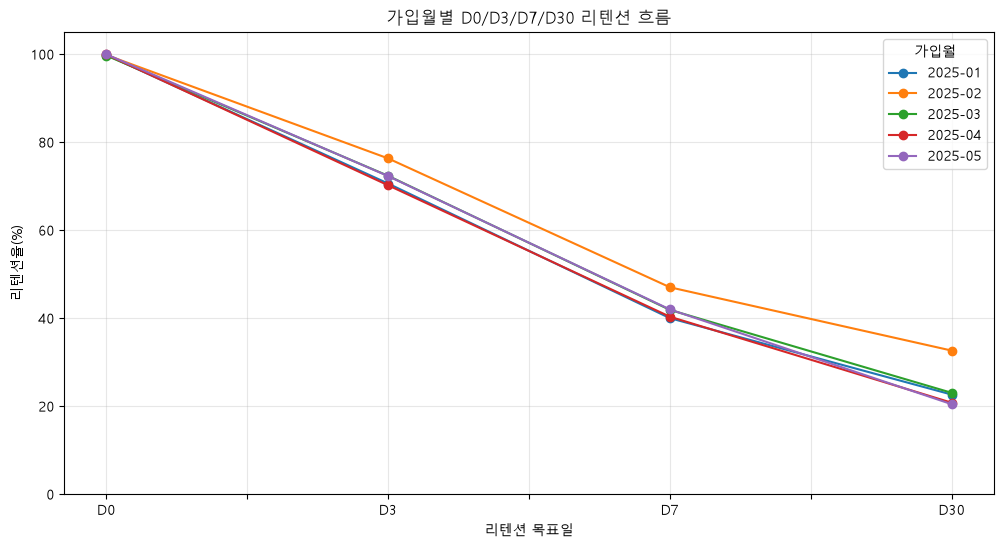

In [12]:
cohort_retention_graph_data = cohort_retention_summary.copy()
cohort_retention_graph_data["retention_label"] = cohort_retention_graph_data["retention_label"].astype(str)

cohort_retention_plot_data = (
    cohort_retention_graph_data
    .pivot(index="retention_label", columns="signup_month", values="retention_rate")
    .reindex(retention_order)
)

ax = cohort_retention_plot_data.plot(marker="o", figsize=(12, 6))
ax.set_title("가입월별 D0/D3/D7/D30 리텐션 흐름")
ax.set_xlabel("리텐션 목표일")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(title="가입월")
plt.show()

### 가입월별 D30 리텐션 비교

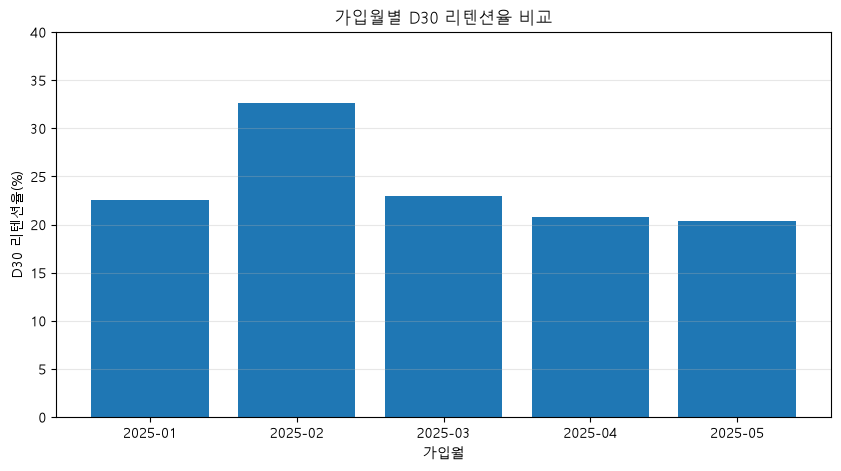

In [13]:
d30_retention_plot_data = (
    cohort_retention_graph_data
    .loc[cohort_retention_graph_data["retention_label"].eq("D30"), ["signup_month", "retention_rate"]]
    .sort_values("signup_month")
)

plt.figure(figsize=(10, 5))
plt.bar(
    d30_retention_plot_data["signup_month"],
    d30_retention_plot_data["retention_rate"]
)
plt.title("가입월별 D30 리텐션율 비교")
plt.xlabel("가입월")
plt.ylabel("D30 리텐션율(%)")
plt.ylim(0, 40)
plt.grid(axis="y", alpha=0.3)
plt.show()

### 분석 결과 해석
전체적으로 D0 리텐션은 모든 가입월에서 약 99.7% 이상으로 매우 높다.  
따라서 가입 직후 앱을 처음 실행하는 단계는 큰 병목으로 보기 어렵다.

반면 D3, D7, D30으로 갈수록 리텐션이 빠르게 낮아진다.  
특히 D7 리텐션은 대부분의 가입월에서 40% 초반 수준까지 내려가고, D30 리텐션은 20% 초반 수준까지 하락한다.

2월 가입자는 가입자 수가 가장 많았지만, D3 76.28%, D7 46.99%, D30 32.60%로 가장 높은 리텐션을 보인다.  
따라서 2월 가입자 수 급증 자체를 리텐션 하락의 직접 원인으로 보기는 어렵다.

오히려 4월과 5월 가입자는 D30 리텐션이 각각 20.75%, 20.41%로 낮다.  
이는 최근 가입 코호트에서 장기 잔존이 약해졌을 가능성을 보여준다.


## 2. 가입월별 리텐션율 표 생성

In [14]:
# 가입월별 리텐션율 표
retention_rate_matrix = (
    cohort_retention_summary
    .pivot(index="signup_month", columns="retention_label", values="retention_rate")
    .reset_index()
)

# 가입월별 리텐션 유지 사용자 수 표
retained_count_matrix = (
    cohort_retention_summary
    .pivot(index="signup_month", columns="retention_label", values="retained_user_count")
    .reset_index()
)

# 가입월별 리텐션 산정 가능 사용자 수 표
calculation_target_matrix = (
    cohort_retention_summary
    .pivot(index="signup_month", columns="retention_label", values="calculation_target_user_count")
    .reset_index()
)

print("가입월별 리텐션율")
display(retention_rate_matrix)

print("가입월별 리텐션 유지 사용자 수")
display(retained_count_matrix)

print("가입월별 리텐션 산정 가능 사용자 수")
display(calculation_target_matrix)

가입월별 리텐션율


retention_label,signup_month,D0,D3,D7,D30
0,2025-01,99.81,70.57,39.97,22.60
1,2025-02,99.79,76.28,46.99,32.60
2,2025-03,99.66,72.32,41.85,23.00
3,2025-04,99.90,70.17,40.30,20.75
4,2025-05,99.94,72.26,41.95,20.41


가입월별 리텐션 유지 사용자 수


retention_label,signup_month,D0,D3,D7,D30
0,2025-01,2120,1499,849,480
1,2025-02,4375,3344,2060,1178
2,2025-03,1775,1288,734,488
3,2025-04,2080,1461,839,432
4,2025-05,1787,1292,750,365


가입월별 리텐션 산정 가능 사용자 수


retention_label,signup_month,D0,D3,D7,D30
0,2025-01,2124,2124,2124,2124
1,2025-02,4384,4384,4384,3613
2,2025-03,1781,1781,1754,2122
3,2025-04,2082,2082,2082,2082
4,2025-05,1788,1788,1788,1788


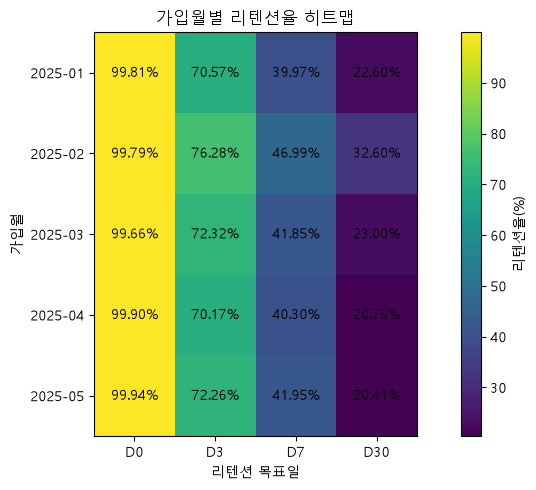

In [15]:
# 행: 가입월, 열: D0/D3/D7/D30, 값: 리텐션율
retention_rate_heatmap_data = (
    retention_rate_matrix
    .set_index("signup_month")[retention_order]
    .astype(float)
)

fig, ax = plt.subplots(figsize=(9, 5))
heatmap = ax.imshow(retention_rate_heatmap_data.values)

ax.set_title("가입월별 리텐션율 히트맵")
ax.set_xlabel("리텐션 목표일")
ax.set_ylabel("가입월")

ax.set_xticks(range(len(retention_rate_heatmap_data.columns)))
ax.set_xticklabels(retention_rate_heatmap_data.columns)
ax.set_yticks(range(len(retention_rate_heatmap_data.index)))
ax.set_yticklabels(retention_rate_heatmap_data.index)

for y in range(retention_rate_heatmap_data.shape[0]):
    for x in range(retention_rate_heatmap_data.shape[1]):
        value = retention_rate_heatmap_data.iloc[y, x]
        ax.text(x, y, f"{value:.2f}%", ha="center", va="center")

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("리텐션율(%)")

plt.tight_layout()
plt.show()

### 분석 결과 해석
가입월별 리텐션율을 보면 모든 코호트에서 D0 리텐션은 99% 이상으로 높게 나타난다.        
하지만 D3, D7, D30으로 갈수록 리텐션율은 점차 감소한다.

D30 기준으로는 2월 코호트가 32.60%로 가장 높고, 4월과 5월 코호트는 각각 20.75%, 20.41%로 낮게 나타난다.

다만 2월 D30과 3월 초반 D0/D3/D7 일부는 로그 수집 장애기간과 겹칠 수 있다.      
따라서 해당 구간은 단순 수치만으로 해석하기보다는, 최종 보고서에서 해석 주의 구간으로 두고 분석해야 한다.

## 3. 이탈 구간 확인

D0 → D3, D3 → D7, D7 → D30 구간별 하락폭을 계산한다.  
이를 통해 가입 이후 어느 시점에서 이탈이 가장 크게 발생하는지 확인한다.

In [16]:
# 15. 리텐션 하락폭

# 가입월별 리텐션율 표 복사
retention_drop_summary = retention_rate_matrix.copy()

# 가입 당일에서 D3까지의 하락폭
retention_drop_summary["D0_to_D3_drop_pp"] = (
    retention_drop_summary["D0"] - retention_drop_summary["D3"]
).round(2)

# D3에서 D7까지의 하락폭
retention_drop_summary["D3_to_D7_drop_pp"] = (
    retention_drop_summary["D3"] - retention_drop_summary["D7"]
).round(2)

# D7에서 D30까지의 하락폭
retention_drop_summary["D7_to_D30_drop_pp"] = (
    retention_drop_summary["D7"] - retention_drop_summary["D30"]
).round(2)

# D0에서 D30까지 전체 하락폭
retention_drop_summary["D0_to_D30_drop_pp"] = (
    retention_drop_summary["D0"] - retention_drop_summary["D30"]
).round(2)

# 보고서에 필요한 컬럼 정리
retention_drop_summary = retention_drop_summary[[
    "signup_month",        # 사용자의 가입월
    "D0", "D3", "D7", "D30", # 가입후 Dn까지 리텐션율
    "D0_to_D3_drop_pp",    # D0에서 D3까지 감소한 리텐션 폭
    "D3_to_D7_drop_pp",    # D3에서 D7까지 감소한 리텐션 폭
    "D7_to_D30_drop_pp",   # D7에서 D30까지 감소한 리텐션 폭
    "D0_to_D30_drop_pp"    # D0에서 D30까지 전체 감소한 리텐션 폭
]]

display(retention_drop_summary)

retention_label,signup_month,D0,D3,D7,D30,D0_to_D3_drop_pp,D3_to_D7_drop_pp,D7_to_D30_drop_pp,D0_to_D30_drop_pp
0,2025-01,99.81,70.57,39.97,22.60,29.24,30.60,17.37,77.21
1,2025-02,99.79,76.28,46.99,32.60,23.51,29.29,14.39,67.19
2,2025-03,99.66,72.32,41.85,23.00,27.34,30.47,18.85,76.66
3,2025-04,99.90,70.17,40.30,20.75,29.73,29.87,19.55,79.15
4,2025-05,99.94,72.26,41.95,20.41,27.68,30.31,21.54,79.53


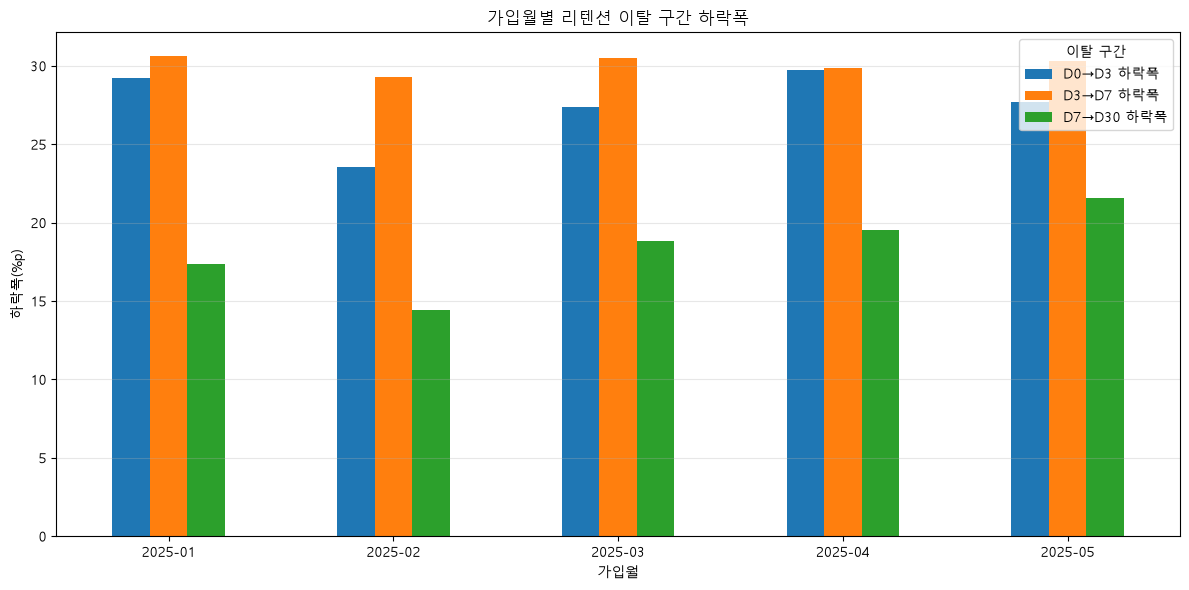

In [17]:
#  가입월별 리텐션 이탈 구간 하락폭 그래프
drop_plot_data = (
    retention_drop_summary
    .set_index("signup_month")[[
        "D0_to_D3_drop_pp",
        "D3_to_D7_drop_pp",
        "D7_to_D30_drop_pp"
    ]]
)

drop_plot_data.columns = [
    "D0→D3 하락폭",
    "D3→D7 하락폭",
    "D7→D30 하락폭"
]

ax = drop_plot_data.plot(kind="bar", figsize=(12, 6))
ax.set_title("가입월별 리텐션 이탈 구간 하락폭")
ax.set_xlabel("가입월")
ax.set_ylabel("하락폭(%p)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="이탈 구간")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 분석 결과 해석

가장 반복적으로 큰 이탈이 발생하는 구간은 **D3 → D7 구간**이다.  
모든 가입월에서 D3 → D7 하락폭이 약 29~31%p 수준으로 나타난다.

즉, 사용자가 가입 직후 3일 차까지는 어느 정도 남아 있지만, 7일 차로 넘어가는 과정에서 큰 폭으로 이탈한다.  
따라서 리텐션 개선의 1차 타겟 구간은 가입 직후가 아니라 **가입 후 3일 차부터 7일 차 사이**로 보는 것이 적절하다.

또한 D7 → D30 하락폭은 최근 코호트로 갈수록 커지는 흐름이 있다.  
특히 5월 코호트는 D7 → D30 하락폭이 21.54%p로 가장 크다.  
이는 초기 사용 후 장기 루틴으로 이어지는 과정이 약해졌을 가능성을 보여준다.

## 4. 로그 수집 장애기간 영향 확인

In [18]:
# 장애 기간과 겹친 목표일이 1명 이상 있는 코호트만 선택
issue_sensitive_cohort_check = cohort_retention_summary[
    cohort_retention_summary["log_issue_target_user_count"] > 0
].copy()

# 정상 산정 리텐션율과 Raw 리텐션율의 차이 계산
issue_sensitive_cohort_check["raw_vs_normal_gap_pp"] = (
    issue_sensitive_cohort_check["retention_rate"]
    - issue_sensitive_cohort_check["raw_retention_rate"]
).round(2)

# 확인에 필요한 컬럼만 정리합니다.
issue_sensitive_cohort_check = issue_sensitive_cohort_check[[
    "signup_month",                    # 사용자의 가입월
    "retention_label",                 # 리텐션 기준일 라벨: D0, D3, D7, D30
    "cohort_user_count",               # 해당 가입월 전체 사용자 수
    "calculation_target_user_count",   # 리텐션 계산에 실제로 사용한 사용자 수
    "log_issue_target_user_count",     # 로그 수집 장애 기간의 영향을 받을 수 있는 사용자 수
    "retention_rate",                  # 장애 기간 영향을 고려한 최종 리텐션율
    "raw_retention_rate",              # 장애 기간 사용자를 제외하지 않은 원본 기준 리텐션율
    "raw_vs_normal_gap_pp"             # 원본 리텐션율과 최종 리텐션율의 차이
]]

display(issue_sensitive_cohort_check)

,signup_month,retention_label,cohort_user_count,calculation_target_user_count,log_issue_target_user_count,retention_rate,raw_retention_rate,raw_vs_normal_gap_pp
7,2025-02,D30,4384,3613,771,32.60,29.01,3.59
8,2025-03,D0,2122,1781,341,99.66,88.83,10.83
9,2025-03,D3,2122,1781,341,72.32,64.66,7.66
10,2025-03,D7,2122,1754,368,41.85,36.66,5.19


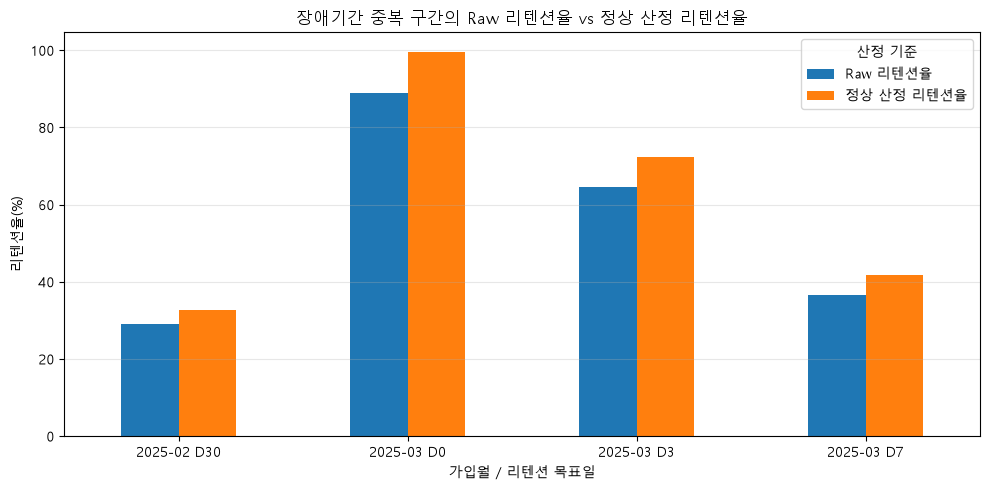

In [19]:
issue_sensitive_plot_data = issue_sensitive_cohort_check.copy()
issue_sensitive_plot_data["cohort_target"] = (
    issue_sensitive_plot_data["signup_month"].astype(str)
    + " "
    + issue_sensitive_plot_data["retention_label"].astype(str)
)

issue_sensitive_plot_data = issue_sensitive_plot_data.set_index("cohort_target")[[
    "raw_retention_rate",
    "retention_rate"
]]

issue_sensitive_plot_data.columns = [
    "Raw 리텐션율",
    "정상 산정 리텐션율"
]

ax = issue_sensitive_plot_data.plot(kind="bar", figsize=(10, 5))
ax.set_title("장애기간 중복 구간의 Raw 리텐션율 vs 정상 산정 리텐션율")
ax.set_xlabel("가입월 / 리텐션 목표일")
ax.set_ylabel("리텐션율(%)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="산정 기준")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 분석 결과 해석

장애기간 영향은 2월 D30과 3월 D0/D3/D7에서 발생한다.

특히 3월 D0는 전체 기준으로 보면 88.83%까지 낮아지지만, 장애기간 중복 사용자를 제외한 정상 산정 가능 기준에서는 99.66%로 회복된다.  
따라서 3월 초반 리텐션을 그대로 비교하면 로그 수집 장애로 인한 과소평가가 발생할 수 있다.

2월 D30도 장애기간 중복 사용자가 771명 존재한다.  
다만 정상 산정 가능 기준으로 보더라도 32.60%로 가장 높은 D30 리텐션을 보이기 때문에, 2월 코호트는 여전히 상대적으로 좋은 코호트로 해석할 수 있다.

# 최종 해석

이번 코호트 분석에서 확인한 핵심 내용은 다음과 같다.

1. **D0 리텐션은 모든 가입월에서 약 99.7% 이상**이다.  
   가입 직후 앱실행 단계는 큰 문제로 보기 어렵다.

2. **가장 큰 이탈 구간은 D3 → D7 구간**이다.  
   모든 가입월에서 이 구간의 하락폭이 약 29~31%p 수준으로 반복된다.

3. **D30 리텐션은 2월 코호트가 가장 높고, 4~5월 코호트가 낮다.**  
   2월 가입자 수 급증이 리텐션 악화로 바로 이어졌다고 보기는 어렵다.

4. **최근 코호트에서는 D7 이후 D30까지 이어지는 장기 잔존이 약하다.**  
   특히 5월 코호트는 D7 → D30 하락폭이 21.54%p로 가장 크다.

5. **장애기간 영향은 반드시 분리해서 해석해야 한다.**  
   3월 D0/D3/D7은 장애기간을 포함하면 리텐션이 과소평가될 수 있다.


| 핵심 내용                                | 해석                                        |
| ------------------------------------ | ----------------------------------------- |
| D0 리텐션은 모든 가입월에서 약 99.7% 이상          | 가입 직후 앱실행 단계는 큰 문제로 보기 어렵다.               |
| 가장 큰 이탈 구간은 D3 → D7                  | 모든 가입월에서 해당 구간의 하락폭이 약 29~31%p 수준으로 반복된다. |
| D30 리텐션은 2월 코호트가 가장 높고, 4~5월 코호트가 낮음 | 2월 가입자 수 급증이 리텐션 악화로 바로 이어졌다고 보기는 어렵다.    |
| 최근 코호트는 D7 이후 D30까지 이어지는 장기 잔존이 약함   | 특히 5월 코호트는 D7 → D30 하락폭이 21.54%p로 가장 크다.  |
| 장애기간 영향은 분리해서 해석 필요                  | 3월 D0/D3/D7은 장애기간을 포함하면 리텐션이 과소평가될 수 있다.  |


---

# 리텐션 하락 원인 분석

| 우선순위 | 다음에 확인할 것                       | 필요한 이유                    | 분석 결과 활용 방향                                  |
| ---: | ------------------------------- | ------------------------- | -------------------------------------------- |
|    1 | 온보딩 완료 여부에 따라 리텐션이 달라지는가?       | 초기 경험의 질이 리텐션에 영향을 주는지 확인 | 온보딩 완료자가 D7/D30에서 더 높다면, 초기 진입 경험 개선이 핵심     |
|    2 | 첫 7일 내 챌린지 탐색/참여 경험자가 더 오래 남는가? | 과제 가설의 핵심 검증              | 챌린지 경험자가 D30이 높다면, 첫 7일 내 챌린지 유도 전략 제안 가능    |
|    3 | 알림 수신/오픈 여부가 리텐션과 연결되는가?        | 알림보다 기능 경험이 중요한지 비교       | 알림보다 챌린지/온보딩 영향이 크면, 단순 알림 증대보다 기능 경험 강화로 연결 |
|    4 | 가입경로별로 리텐션 차이가 있는가?             | 2월 가입자 급증이 유입 품질 문제인지 확인  | 특정 유입경로 리텐션이 낮다면 마케팅 유입 품질 문제 제기 가능          |
|    5 | 기기별로 리텐션 차이가 있는가?               | 특정 환경에서 이탈이 큰지 확인         | 특정 기기 리텐션이 낮으면 사용성/기술 이슈 가능성 제기              |


## 분석 방향 설정

가입월별 코호트 분석에서 **D3 → D7 구간에서 가장 큰 이탈이 반복적으로 발생**한다는 점을 확인했다.       
사용자가 가입 초기에 어떤 행동을 했는지에 따라 D7/D30 리텐션이 달라지는지 확인한다.

단, 2025년 3월 10일 ~ 3월 14일 로그 수집 장애기간은 분석 지표별로 다르게 처리한다.

| 구분 | 처리 기준 |
|---|---|
| 리텐션 목표일이 장애기간과 겹치는 경우 | 미방문으로 보지 않고 관측 불가로 판단하여 주 분석에서 제외 |
| 가입 후 첫 7일 행동 관측 구간이 장애기간과 겹치는 경우 | 챌린지/알림/온보딩 경험이 과소기록될 수 있으므로 별도 플래그 처리 |
| 리텐션 하락 원인 분석 | 첫 7일 장애기간 중복 사용자를 제외한 결과를 주 분석으로 사용 |
| 민감도 확인 | 장애기간 중복 사용자를 포함한 결과와 제외한 결과를 함께 비교 |
| Event_Type 결측 | 임의 추정하지 않고 해당 이벤트 유형 기반 분석에서는 제외 |

In [20]:
# 리텐션 하락 원인 분석용 베이스 테이블 생성

behavior_retention_base = user_retention_judgement_base.merge(
    user_profile[[
        "user_id",
        "signup_channel",
        "device",
        "is_onboarding_completed"
    ]],
    on="user_id",
    how="left"
)

behavior_retention_base["onboarding_group"] = np.where(
    behavior_retention_base["is_onboarding_completed"],
    "온보딩 완료",
    "온보딩 미완료"
)

# 첫 7일 행동 관측 구간과 로그 장애기간 중복 여부 표시
first7_issue_user = user_profile[[
    "user_id",
    "signup_day",
    "signup_month"
]].copy()

first7_issue_user["first7_start_date"] = first7_issue_user["signup_day"]

first7_issue_user["first7_end_date"] = (
    first7_issue_user["signup_day"]
    + pd.to_timedelta(6, unit="D")
)

first7_issue_user["is_first7_log_issue_overlap"] = (
    first7_issue_user["first7_start_date"].le(issue_end)
    & first7_issue_user["first7_end_date"].ge(issue_start)
)

# 가입월별 첫 7일 장애기간 중복 사용자 규모 확인
first7_issue_summary = (
    first7_issue_user
    .groupby("signup_month", as_index=False)
    .agg(
        user_count=("user_id", "nunique"),
        first7_log_issue_overlap_user_count=("is_first7_log_issue_overlap", "sum")
    )
)

first7_issue_summary["first7_log_issue_overlap_rate"] = (
    first7_issue_summary["first7_log_issue_overlap_user_count"]
    / first7_issue_summary["user_count"]
    * 100
).round(2)

# 리텐션 하락 원인 분석용 베이스 테이블에 첫 7일 장애기간 중복 여부 결합
behavior_retention_base = behavior_retention_base.merge(
    first7_issue_user[[
        "user_id",
        "first7_start_date",
        "first7_end_date",
        "is_first7_log_issue_overlap"
    ]],
    on="user_id",
    how="left"
)

# 가입 후 7일 이내 이벤트만 분리
first_7day_event_log = event_log_retention_base[
    event_log_retention_base["event_day_from_signup"].between(0, 6)
].copy()

print("리텐션 하락 원인 분석용 베이스 테이블 shape:", behavior_retention_base.shape)
print("가입 후 7일 이내 이벤트 로그 shape:", first_7day_event_log.shape)

print("가입월별 첫 7일 장애기간 중복 사용자 규모")
display(first7_issue_summary)

display(behavior_retention_base.head())
display(first_7day_event_log.head())

리텐션 하락 원인 분석용 베이스 테이블 shape: (50000, 22)
가입 후 7일 이내 이벤트 로그 shape: (501275, 24)
가입월별 첫 7일 장애기간 중복 사용자 규모


,signup_month,user_count,first7_log_issue_overlap_user_count,first7_log_issue_overlap_rate
0,2025-01,2124,0,0.00
1,2025-02,4384,0,0.00
2,2025-03,2122,773,36.43
3,2025-04,2082,0,0.00
4,2025-05,1788,0,0.00


,user_id,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,retention_day,target_date,retention_label,is_target_observable,is_target_log_issue_period,is_retention_calculation_target,retention_target_status,has_active_event_on_target_date,is_retained_raw,is_retained_for_calculation,signup_channel,device,is_onboarding_completed,onboarding_group,first7_start_date,first7_end_date,is_first7_log_issue_overlap
0,U0000001,2025-01-25,2025-01,False,False,0,2025-01-25,D0,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,True,온보딩 완료,2025-01-25,2025-01-31,False
1,U0000001,2025-01-25,2025-01,False,False,3,2025-01-28,D3,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,True,온보딩 완료,2025-01-25,2025-01-31,False
2,U0000001,2025-01-25,2025-01,False,False,7,2025-02-01,D7,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,True,온보딩 완료,2025-01-25,2025-01-31,False
3,U0000001,2025-01-25,2025-01,False,False,30,2025-02-24,D30,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,True,온보딩 완료,2025-01-25,2025-01-31,False
4,U0000002,2025-05-06,2025-05,False,False,0,2025-05-06,D0,True,False,True,정상 산정 가능,True,True,True,오가닉,iOS,False,온보딩 미완료,2025-05-06,2025-05-12,False


,user_id,event_time,event_type,session_id,notification_type,is_event_type_missing,event_type_display,is_notification_event,is_session_id_missing,is_session_missing_expected,is_session_missing_unexpected,notification_type_display,event_date,event_month,event_weekday,event_hour,is_log_issue_period,signup_day,signup_month,is_no_event_user,is_signup_log_issue_period,event_day_from_signup,is_retention_active_event,is_event_before_signup
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,False,앱실행,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-25,2025-01,False,False,0,True,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,False,온보딩_완료,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-25,2025-01,False,False,0,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,False,챌린지_탐색,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-25,2025-01,False,False,0,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,False,챌린지참여,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-25,2025-01,False,False,0,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,False,알림수신,True,True,True,False,광고성,2025-01-25,2025-01,토,20,False,2025-01-25,2025-01,False,False,0,False,False


## 1. 온보딩 완료 여부별 리텐션 분석

### 분석 목적
가입월별 코호트 분석에서 D3 → D7 구간의 이탈폭이 가장 크게 나타났다.    
따라서 온보딩 완료 여부에 따라 D3, D7, D30 리텐션이 어떻게 달라지는지 확인한다.

특히 D3 → D7 구간의 하락폭이 온보딩 완료자와 미완료자 사이에서 다르게 나타나는지 확인하여, 초기 이탈이 온보딩 경험과 연결되는지 검토한다.       
온보딩 완료자의 D7/D30 리텐션이 높고 D3 → D7 하락폭이 작다면, 리텐션 하락 원인은 단순 유입 문제가 아니라 초기 진입 경험의 품질 문제와 연결될 수 있다.

In [21]:
# 온보딩 완료 여부별 리텐션 분석
# 주 분석은 리텐션 목표일 정상 산정 대상 + 첫 7일 장애기간 비중복 사용자 기준

onboarding_group_order = [
    "온보딩 완료",
    "온보딩 미완료"
]

# 장애기간 중복 사용자 포함 결과
onboarding_include_issue_summary = (
    behavior_retention_base[
        behavior_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["onboarding_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

onboarding_include_issue_summary["retention_rate"] = (
    onboarding_include_issue_summary["retained_user_count"]
    / onboarding_include_issue_summary["target_user_count"]
    * 100
).round(2)

onboarding_include_issue_summary["analysis_scenario"] = "장애 영향 포함"

# 장애기간 중복 사용자 제외 결과
onboarding_retention_summary = (
    behavior_retention_base[
        behavior_retention_base["is_retention_calculation_target"]
        & ~behavior_retention_base["is_first7_log_issue_overlap"].fillna(False)
    ]
    .groupby(["onboarding_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

onboarding_retention_summary["retention_rate"] = (
    onboarding_retention_summary["retained_user_count"]
    / onboarding_retention_summary["target_user_count"]
    * 100
).round(2)

onboarding_retention_summary["analysis_scenario"] = "장애 영향 제외"

# 장애기간 포함 결과와 제외 결과 비교
onboarding_issue_sensitivity_base = pd.concat(
    [
        onboarding_include_issue_summary,
        onboarding_retention_summary
    ],
    ignore_index=True
)

onboarding_issue_sensitivity_check = (
    onboarding_issue_sensitivity_base
    .pivot_table(
        index=["onboarding_group", "retention_label"],
        columns="analysis_scenario",
        values="retention_rate",
        aggfunc="first",
        observed=False
    )
    .reset_index()
)

onboarding_issue_sensitivity_check["exclude_vs_include_gap_pp"] = (
    onboarding_issue_sensitivity_check["장애 영향 제외"]
    - onboarding_issue_sensitivity_check["장애 영향 포함"]
).round(2)

# 온보딩 그룹 순서 지정
onboarding_retention_summary["onboarding_group"] = pd.Categorical(
    onboarding_retention_summary["onboarding_group"],
    categories=onboarding_group_order,
    ordered=True
)

onboarding_issue_sensitivity_check["onboarding_group"] = pd.Categorical(
    onboarding_issue_sensitivity_check["onboarding_group"],
    categories=onboarding_group_order,
    ordered=True
)

# 리텐션 목표일 순서 지정
onboarding_retention_summary["retention_label"] = pd.Categorical(
    onboarding_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

onboarding_issue_sensitivity_check["retention_label"] = pd.Categorical(
    onboarding_issue_sensitivity_check["retention_label"],
    categories=retention_order,
    ordered=True
)

# 표와 그래프 확인용 정렬
onboarding_retention_summary = onboarding_retention_summary.sort_values(
    ["onboarding_group", "retention_label"]
)

onboarding_issue_sensitivity_check = onboarding_issue_sensitivity_check.sort_values(
    ["onboarding_group", "retention_label"]
)

# 온보딩 그룹별 리텐션율 표
onboarding_retention_rate_table = (
    onboarding_retention_summary
    .pivot(index="onboarding_group", columns="retention_label", values="retention_rate")
    .reindex(onboarding_group_order)
)

# 온보딩 그룹별 유지 사용자 수 표
onboarding_retention_count_table = (
    onboarding_retention_summary
    .pivot(index="onboarding_group", columns="retention_label", values="retained_user_count")
    .reindex(onboarding_group_order)
)

print("온보딩 완료 여부별 리텐션율")
display(onboarding_retention_rate_table)

print("온보딩 완료 여부별 리텐션 유지 사용자 수")
display(onboarding_retention_count_table)

print("온보딩 완료 여부별 장애기간 포함/제외 민감도 확인")
display(onboarding_issue_sensitivity_check)


온보딩 완료 여부별 리텐션율


retention_label,D0,D3,D7,D30
onboarding_group,,,,
온보딩 완료,99.85,76.55,47.76,30.73
온보딩 미완료,99.82,70.18,39.24,20.79


온보딩 완료 여부별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
onboarding_group,,,,
온보딩 완료,5455,4182,2596,1565
온보딩 미완료,6253,4396,2441,1219


온보딩 완료 여부별 장애기간 포함/제외 민감도 확인


analysis_scenario,onboarding_group,retention_label,장애 영향 제외,장애 영향 포함,exclude_vs_include_gap_pp
4,온보딩 완료,D0,99.85,99.81,0.04
5,온보딩 완료,D3,76.55,76.42,0.13
7,온보딩 완료,D7,47.76,47.39,0.37
6,온보딩 완료,D30,30.73,30.30,0.43
0,온보딩 미완료,D0,99.82,99.83,-0.01
1,온보딩 미완료,D3,70.18,70.21,-0.03
3,온보딩 미완료,D7,39.24,39.53,-0.29
2,온보딩 미완료,D30,20.79,20.72,0.07


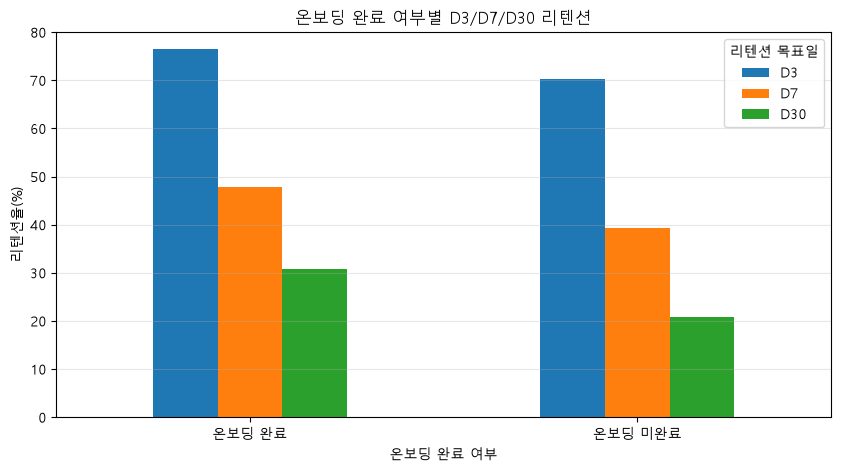

In [22]:
onboarding_plot_data = onboarding_retention_rate_table[["D3", "D7", "D30"]]

ax = onboarding_plot_data.plot(kind="bar", figsize=(10, 5))
ax.set_title("온보딩 완료 여부별 D3/D7/D30 리텐션")
ax.set_xlabel("온보딩 완료 여부")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 80)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

In [23]:
# D3, D7, D30 리텐션율만 복사
onboarding_drop_table = onboarding_retention_rate_table[["D3", "D7", "D30"]].copy()

# D3에서 D7까지의 하락폭을 계산
onboarding_drop_table["D3_to_D7_drop"] = (
    onboarding_drop_table["D3"] - onboarding_drop_table["D7"]
).round(2)

# D7에서 D30까지의 하락폭을 계산
onboarding_drop_table["D7_to_D30_drop"] = (
    onboarding_drop_table["D7"] - onboarding_drop_table["D30"]
).round(2)

print("온보딩 완료 여부별 리텐션 하락폭")
display(onboarding_drop_table)

온보딩 완료 여부별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
onboarding_group,,,,,
온보딩 완료,76.55,47.76,30.73,28.79,17.03
온보딩 미완료,70.18,39.24,20.79,30.94,18.45


### 분석 결과 해석
온보딩 완료자는 미완료자보다 D3, D7, D30 리텐션이 모두 높게 나타났다.

| 구분      |     D3 |     D7 |    D30 |
| ------- | -----: | -----: | -----: |
| 온보딩 완료  | 76.42% | 47.39% | 30.30% |
| 온보딩 미완료 | 70.21% | 39.53% | 20.72% |

온보딩 완료자는 미완료자보다 D7 리텐션이 약8%p, D30 리텐션이 약 9%p 높다.      
따라서 온보딩 완료 여부는 장기 잔존과 연결되는 신호로 볼 수 있다.

다만 D3 → D7 하락폭은 두 그룹 모두 약 29~31%p 수준으로 크게 나타난다.      
따라서 D3 → D7 이탈은 온보딩만으로 설명하기 어렵고, 이후 챌린지 탐색/참여 같은 초기 기능 경험을 추가로 확인할 필요가 있다.

## 2. 첫 7일 내 챌린지 탐색/참여 경험별 리텐션 분석

### 분석 목적
과제에서 제시한 핵심 가설은 **첫 7일 내 루틴 챌린지 경험자가 D30 리텐션이 더 높은지** 확인 하는것.      

다만 앞선 가입월별 코호트 분석에서 가장 큰 이탈 구간이 **D3 → D7**로 확인되었으므로, 여기서는 D30만 보지 않고 D3, D7, D30 리텐션을 함께 비교한다.       
특히나 첫 7일 내 챌린지 탐색/참여 경험 여부에 따라 **D3 → D7 하락폭**과 **D7 → D30 하락폭**이 어떻게 달라지는지 확인한다.


In [24]:
# 첫 7일 이벤트 중 챌린지_탐색, 챌린지참여 이벤트만 집계
challenge_first7_event_count = (
    first_7day_event_log[
        first_7day_event_log["event_type"].isin(["챌린지_탐색", "챌린지참여"])
    ]
    .pivot_table(
        index="user_id",        # 사용자별로 집계
        columns="event_type",   # 이벤트 종류를 컬럼으로 펼침
        values="event_time",    # 이벤트 발생 횟수를 셀 값으로 사용
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

# 챌린지 이벤트가 없어서 NaN인 값은 0으로 변경
challenge_first7_user = user_profile[["user_id"]].merge(
    challenge_first7_event_count,
    on="user_id",
    how="left"
)

# 첫 7일 내 행동에 따라 사용자를 3개 그룹으로 나눔
challenge_first7_user[["챌린지_탐색", "챌린지참여"]] = (
    challenge_first7_user[["챌린지_탐색", "챌린지참여"]]
    .fillna(0)
)

challenge_first7_user["challenge_first7_group"] = np.select(
    [
        challenge_first7_user["챌린지참여"].gt(0),
        challenge_first7_user["챌린지_탐색"].gt(0)
    ],
    [
        "첫 7일 내 챌린지 참여",
        "첫 7일 내 챌린지 탐색만"
    ],
    default="첫 7일 내 챌린지 미경험"
)

# 각 그룹에 사용자가 몇 명 있는지 확인
challenge_group_summary = (
    challenge_first7_user
    .groupby("challenge_first7_group", as_index=False)
    .agg(user_count=("user_id", "nunique"))
)

display(challenge_group_summary)

,challenge_first7_group,user_count
0,첫 7일 내 챌린지 미경험,4276
1,첫 7일 내 챌린지 참여,8185
2,첫 7일 내 챌린지 탐색만,39


In [25]:
# 리텐션 분석용 테이블에 첫 7일 내 챌린지 경험 그룹 결합
challenge_retention_base = behavior_retention_base.merge(
    challenge_first7_user[["user_id", "challenge_first7_group"]],
    on="user_id",
    how="left"
)

# 표와 그래프에서 사용할 챌린지 경험 그룹 순서
challenge_group_order = [
    "첫 7일 내 챌린지 참여",
    "첫 7일 내 챌린지 탐색만",
    "첫 7일 내 챌린지 미경험"
]

# 장애기간 중복 사용자 포함 결과
challenge_include_issue_summary = (
    challenge_retention_base[
        challenge_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["challenge_first7_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

challenge_include_issue_summary["retention_rate"] = (
    challenge_include_issue_summary["retained_user_count"]
    / challenge_include_issue_summary["target_user_count"]
    * 100
).round(2)

challenge_include_issue_summary["analysis_scenario"] = "장애 영향 포함"

# 장애기간 중복 사용자 제외 결과
challenge_retention_summary = (
    challenge_retention_base[
        challenge_retention_base["is_retention_calculation_target"]
        & ~challenge_retention_base["is_first7_log_issue_overlap"].fillna(False)
    ]
    .groupby(["challenge_first7_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

challenge_retention_summary["retention_rate"] = (
    challenge_retention_summary["retained_user_count"]
    / challenge_retention_summary["target_user_count"]
    * 100
).round(2)

challenge_retention_summary["analysis_scenario"] = "장애 영향 제외"

# 장애기간 포함 결과와 제외 결과 비교
challenge_issue_sensitivity_base = pd.concat(
    [
        challenge_include_issue_summary,
        challenge_retention_summary
    ],
    ignore_index=True
)

challenge_issue_sensitivity_check = (
    challenge_issue_sensitivity_base
    .pivot_table(
        index=["challenge_first7_group", "retention_label"],
        columns="analysis_scenario",
        values="retention_rate",
        aggfunc="first",
        observed=False
    )
    .reset_index()
)

challenge_issue_sensitivity_check["exclude_vs_include_gap_pp"] = (
    challenge_issue_sensitivity_check["장애 영향 제외"]
    - challenge_issue_sensitivity_check["장애 영향 포함"]
).round(2)

# 챌린지 경험 그룹 순서 지정
challenge_retention_summary["challenge_first7_group"] = pd.Categorical(
    challenge_retention_summary["challenge_first7_group"],
    categories=challenge_group_order,
    ordered=True
)

challenge_issue_sensitivity_check["challenge_first7_group"] = pd.Categorical(
    challenge_issue_sensitivity_check["challenge_first7_group"],
    categories=challenge_group_order,
    ordered=True
)

# 리텐션 목표일 순서 지정
challenge_retention_summary["retention_label"] = pd.Categorical(
    challenge_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

challenge_issue_sensitivity_check["retention_label"] = pd.Categorical(
    challenge_issue_sensitivity_check["retention_label"],
    categories=retention_order,
    ordered=True
)

# 챌린지 경험 그룹, 리텐션 목표일 기준 정렬
challenge_retention_summary = challenge_retention_summary.sort_values(
    ["challenge_first7_group", "retention_label"]
)

challenge_issue_sensitivity_check = challenge_issue_sensitivity_check.sort_values(
    ["challenge_first7_group", "retention_label"]
)

# 챌린지 경험 그룹별 리텐션율 표 생성
challenge_retention_rate_table = (
    challenge_retention_summary
    .pivot(index="challenge_first7_group", columns="retention_label", values="retention_rate")
    .reindex(challenge_group_order)
)

# 챌린지 경험 그룹별 유지 사용자 수 표 생성
challenge_retention_count_table = (
    challenge_retention_summary
    .pivot(index="challenge_first7_group", columns="retention_label", values="retained_user_count")
    .reindex(challenge_group_order)
)

print("첫 7일 내 챌린지 경험별 리텐션율")
display(challenge_retention_rate_table)

print("첫 7일 내 챌린지 경험별 리텐션 유지 사용자 수")
display(challenge_retention_count_table)

print("첫 7일 내 챌린지 경험별 장애기간 포함/제외 민감도 확인")
display(challenge_issue_sensitivity_check)


첫 7일 내 챌린지 경험별 리텐션율


retention_label,D0,D3,D7,D30
challenge_first7_group,,,,
첫 7일 내 챌린지 참여,99.90,79.72,50.92,32.11
첫 7일 내 챌린지 탐색만,97.37,78.95,50.00,20.59
첫 7일 내 챌린지 미경험,99.75,60.30,28.14,12.38


첫 7일 내 챌린지 경험별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
challenge_first7_group,,,,
첫 7일 내 챌린지 참여,7714,6156,3908,2319
첫 7일 내 챌린지 탐색만,37,30,19,7
첫 7일 내 챌린지 미경험,3957,2392,1110,458


첫 7일 내 챌린지 경험별 장애기간 포함/제외 민감도 확인


analysis_scenario,challenge_first7_group,retention_label,장애 영향 제외,장애 영향 포함,exclude_vs_include_gap_pp
4,첫 7일 내 챌린지 참여,D0,99.90,99.86,0.04
5,첫 7일 내 챌린지 참여,D3,79.72,79.72,0.00
7,첫 7일 내 챌린지 참여,D7,50.92,50.91,0.01
6,첫 7일 내 챌린지 참여,D30,32.11,31.79,0.32
8,첫 7일 내 챌린지 탐색만,D0,97.37,97.37,0.00
9,첫 7일 내 챌린지 탐색만,D3,78.95,79.49,-0.54
11,첫 7일 내 챌린지 탐색만,D7,50.00,51.28,-1.28
10,첫 7일 내 챌린지 탐색만,D30,20.59,22.86,-2.27
0,첫 7일 내 챌린지 미경험,D0,99.75,99.76,-0.01
1,첫 7일 내 챌린지 미경험,D3,60.30,60.07,0.23


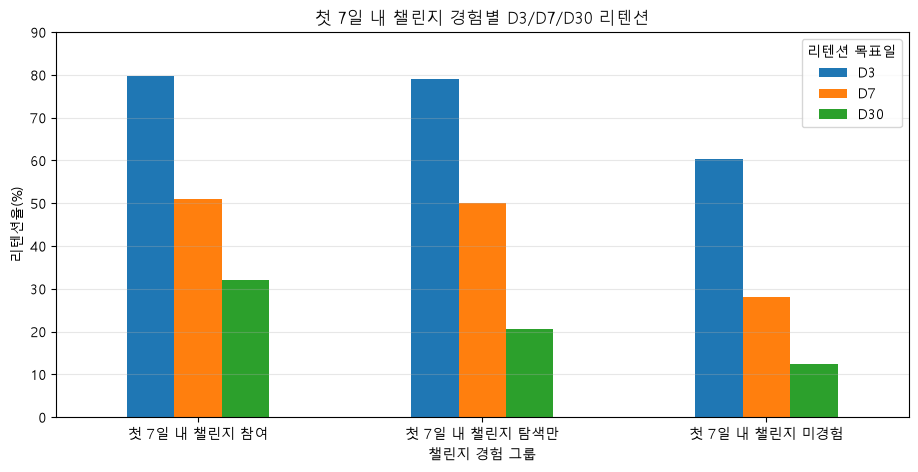

첫 7일 내 챌린지 경험별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
challenge_first7_group,,,,,
첫 7일 내 챌린지 참여,79.72,50.92,32.11,28.80,18.81
첫 7일 내 챌린지 탐색만,78.95,50.00,20.59,28.95,29.41
첫 7일 내 챌린지 미경험,60.30,28.14,12.38,32.16,15.76


In [26]:
challenge_plot_data = challenge_retention_rate_table[["D3", "D7", "D30"]]

ax = challenge_plot_data.plot(kind="bar", figsize=(11, 5))
ax.set_title("첫 7일 내 챌린지 경험별 D3/D7/D30 리텐션")
ax.set_xlabel("챌린지 경험 그룹")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 90)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

challenge_drop_table = challenge_retention_rate_table[["D3", "D7", "D30"]].copy()

challenge_drop_table["D3_to_D7_drop"] = (
    challenge_drop_table["D3"] - challenge_drop_table["D7"]
).round(2)

challenge_drop_table["D7_to_D30_drop"] = (
    challenge_drop_table["D7"] - challenge_drop_table["D30"]
).round(2)

print("첫 7일 내 챌린지 경험별 리텐션 하락폭")
display(challenge_drop_table)

### 분석 결과 해석

첫 7일 내 챌린지 참여자는 미경험자보다 D3, D7, D30 리텐션이 모두 높게 나타났다.

| 구분 | D3 | D7 | D30 |
|---|---:|---:|---:|
| 첫 7일 내 챌린지 참여 | 80.25% | 52.23% | 31.84% |
| 첫 7일 내 챌린지 탐색만 | 77.78% | 47.22% | 21.88% |
| 첫 7일 내 챌린지 미경험 | 57.90% | 24.12% | 11.10% |

챌린지 참여자는 미경험자보다 D7 리텐션이 28.11%p, D30 리텐션이 20.74%p 높다.  
또한 D3 → D7 하락폭도 챌린지 참여자는 28.02%p, 미경험자는 33.78%p로 나타나 미경험자의 초기 이탈폭이 더 크다.

따라서 첫 7일 내 챌린지 참여 여부는 D3 → D7 이탈과 D30 장기 잔존을 설명하는 핵심 신호로 볼 수 있다.  
다만 `챌린지 탐색만` 그룹은 사용자 수가 36명으로 매우 작기 때문에, 해석은 참여자와 미경험자 비교를 중심으로 진행한다.


## 3. 첫 7일 내 알림 수신/오픈 여부별 리텐션 분석

### 분석 목적

알림이 리텐션과 연결되는지 확인하기 위해, 가입 후 7일 이내 알림 이벤트를 기준으로 사용자를 나눈다.      
알림은 단순히 수신 여부만 보는 것이 아니라, 실제로 사용자가 알림을 오픈했는지도 함께 비교한다.


In [27]:
# 첫 7일 이벤트 중 알림수신, 알림오픈만 사용자별 집계
notification_first7_event_count = (
    first_7day_event_log[
        first_7day_event_log["event_type"].isin(["알림수신", "알림오픈"])
    ]
    .pivot_table(
        index="user_id",
        columns="event_type",
        values="event_time",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

# 전체 사용자 목록에 첫 7일 알림 이벤트 횟수 결합
notification_first7_user = user_profile[["user_id"]].merge(
    notification_first7_event_count,
    on="user_id",
    how="left"
)

# 알림 이벤트가 없는 사용자는 결측이므로 0으로 대체
notification_first7_user[["알림수신", "알림오픈"]] = (
    notification_first7_user[["알림수신", "알림오픈"]]
    .fillna(0)
)

# 첫 7일 내 알림 행동 기준 그룹 분류
# 알림 오픈이 수신보다 강한 반응이므로 오픈 여부를 먼저 판정
notification_first7_user["notification_first7_group"] = np.select(
    [
        notification_first7_user["알림오픈"].gt(0),
        notification_first7_user["알림수신"].gt(0)
    ],
    [
        "첫 7일 내 알림 오픈",
        "첫 7일 내 알림 수신만"
    ],
    default="첫 7일 내 알림 없음"
)

# 알림 그룹별 사용자 수 확인
notification_group_summary = (
    notification_first7_user
    .groupby("notification_first7_group", as_index=False)
    .agg(user_count=("user_id", "nunique"))
)

display(notification_group_summary)

,notification_first7_group,user_count
0,첫 7일 내 알림 수신만,4137
1,첫 7일 내 알림 없음,4459
2,첫 7일 내 알림 오픈,3904


In [28]:
# 리텐션 분석용 테이블에 첫 7일 알림 반응 그룹 결합
notification_retention_base = behavior_retention_base.merge(
    notification_first7_user[["user_id", "notification_first7_group"]],
    on="user_id",
    how="left"
)

# 표와 그래프에서 사용할 알림 반응 그룹 순서
notification_group_order = [
    "첫 7일 내 알림 오픈",
    "첫 7일 내 알림 수신만",
    "첫 7일 내 알림 없음"
]

# 장애기간 중복 사용자 포함 결과
notification_include_issue_summary = (
    notification_retention_base[
        notification_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["notification_first7_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

notification_include_issue_summary["retention_rate"] = (
    notification_include_issue_summary["retained_user_count"]
    / notification_include_issue_summary["target_user_count"]
    * 100
).round(2)

notification_include_issue_summary["analysis_scenario"] = "장애 영향 포함"

# 장애기간 중복 사용자 제외 결과
notification_retention_summary = (
    notification_retention_base[
        notification_retention_base["is_retention_calculation_target"]
        & ~notification_retention_base["is_first7_log_issue_overlap"].fillna(False)
    ]
    .groupby(["notification_first7_group", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

notification_retention_summary["retention_rate"] = (
    notification_retention_summary["retained_user_count"]
    / notification_retention_summary["target_user_count"]
    * 100
).round(2)

notification_retention_summary["analysis_scenario"] = "장애 영향 제외"

# 장애기간 포함 결과와 제외 결과 비교
notification_issue_sensitivity_base = pd.concat(
    [
        notification_include_issue_summary,
        notification_retention_summary
    ],
    ignore_index=True
)

notification_issue_sensitivity_check = (
    notification_issue_sensitivity_base
    .pivot_table(
        index=["notification_first7_group", "retention_label"],
        columns="analysis_scenario",
        values="retention_rate",
        aggfunc="first",
        observed=False
    )
    .reset_index()
)

notification_issue_sensitivity_check["exclude_vs_include_gap_pp"] = (
    notification_issue_sensitivity_check["장애 영향 제외"]
    - notification_issue_sensitivity_check["장애 영향 포함"]
).round(2)

# 알림 반응 그룹 순서 지정
notification_retention_summary["notification_first7_group"] = pd.Categorical(
    notification_retention_summary["notification_first7_group"],
    categories=notification_group_order,
    ordered=True
)

notification_issue_sensitivity_check["notification_first7_group"] = pd.Categorical(
    notification_issue_sensitivity_check["notification_first7_group"],
    categories=notification_group_order,
    ordered=True
)

# 리텐션 목표일 순서 지정
notification_retention_summary["retention_label"] = pd.Categorical(
    notification_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

notification_issue_sensitivity_check["retention_label"] = pd.Categorical(
    notification_issue_sensitivity_check["retention_label"],
    categories=retention_order,
    ordered=True
)

# 알림 반응 그룹, 리텐션 목표일 기준 정렬
notification_retention_summary = notification_retention_summary.sort_values(
    ["notification_first7_group", "retention_label"]
)

notification_issue_sensitivity_check = notification_issue_sensitivity_check.sort_values(
    ["notification_first7_group", "retention_label"]
)

# 알림 반응 그룹별 리텐션율 표 생성
notification_retention_rate_table = (
    notification_retention_summary
    .pivot(index="notification_first7_group", columns="retention_label", values="retention_rate")
    .reindex(notification_group_order)
)

# 알림 반응 그룹별 유지 사용자 수 표 생성
notification_retention_count_table = (
    notification_retention_summary
    .pivot(index="notification_first7_group", columns="retention_label", values="retained_user_count")
    .reindex(notification_group_order)
)

print("첫 7일 내 알림 수신/오픈 여부별 리텐션율")
display(notification_retention_rate_table)

print("첫 7일 내 알림 수신/오픈 여부별 리텐션 유지 사용자 수")
display(notification_retention_count_table)

print("첫 7일 내 알림 수신/오픈 여부별 장애기간 포함/제외 민감도 확인")
display(notification_issue_sensitivity_check)


첫 7일 내 알림 수신/오픈 여부별 리텐션율


retention_label,D0,D3,D7,D30
notification_first7_group,,,,
첫 7일 내 알림 오픈,99.89,88.68,53.32,32.20
첫 7일 내 알림 수신만,99.77,58.74,31.77,18.29
첫 7일 내 알림 없음,99.85,72.53,44.72,26.07


첫 7일 내 알림 수신/오픈 여부별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
notification_first7_group,,,,
첫 7일 내 알림 오픈,3740,3320,1985,1112
첫 7일 내 알림 수신만,3849,2266,1217,668
첫 7일 내 알림 없음,4119,2992,1835,1004


첫 7일 내 알림 수신/오픈 여부별 장애기간 포함/제외 민감도 확인


analysis_scenario,notification_first7_group,retention_label,장애 영향 제외,장애 영향 포함,exclude_vs_include_gap_pp
8,첫 7일 내 알림 오픈,D0,99.89,99.90,-0.01
9,첫 7일 내 알림 오픈,D3,88.68,88.41,0.27
11,첫 7일 내 알림 오픈,D7,53.32,53.27,0.05
10,첫 7일 내 알림 오픈,D30,32.20,31.75,0.45
0,첫 7일 내 알림 수신만,D0,99.77,99.75,0.02
1,첫 7일 내 알림 수신만,D3,58.74,59.17,-0.43
3,첫 7일 내 알림 수신만,D7,31.77,32.22,-0.45
2,첫 7일 내 알림 수신만,D30,18.29,18.34,-0.05
4,첫 7일 내 알림 없음,D0,99.85,99.81,0.04
5,첫 7일 내 알림 없음,D3,72.53,72.27,0.26


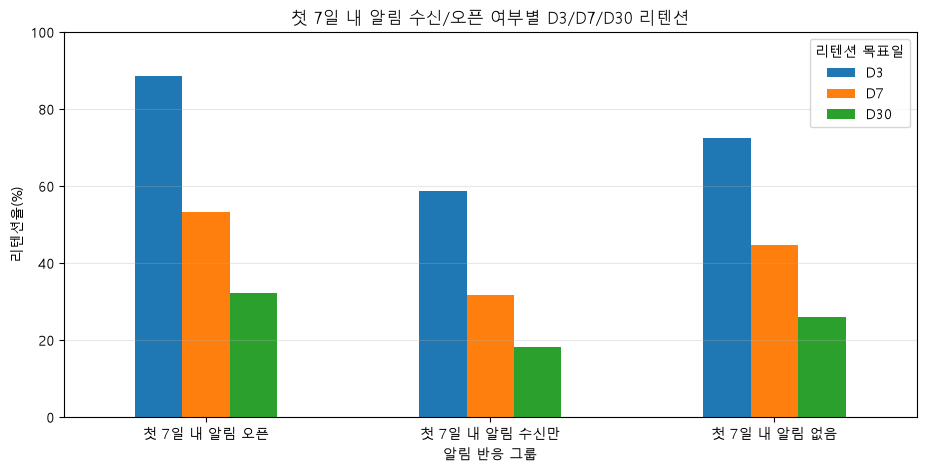

첫 7일 내 알림 수신/오픈 여부별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
notification_first7_group,,,,,
첫 7일 내 알림 오픈,88.68,53.32,32.20,35.36,21.12
첫 7일 내 알림 수신만,58.74,31.77,18.29,26.97,13.48
첫 7일 내 알림 없음,72.53,44.72,26.07,27.81,18.65


In [29]:
notification_plot_data = notification_retention_rate_table[["D3", "D7", "D30"]]

ax = notification_plot_data.plot(kind="bar", figsize=(11, 5))
ax.set_title("첫 7일 내 알림 수신/오픈 여부별 D3/D7/D30 리텐션")
ax.set_xlabel("알림 반응 그룹")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

notification_drop_table = notification_retention_rate_table[["D3", "D7", "D30"]].copy()

notification_drop_table["D3_to_D7_drop"] = (
    notification_drop_table["D3"] - notification_drop_table["D7"]
).round(2)

notification_drop_table["D7_to_D30_drop"] = (
    notification_drop_table["D7"] - notification_drop_table["D30"]
).round(2)

print("첫 7일 내 알림 수신/오픈 여부별 리텐션 하락폭")
display(notification_drop_table)

### 분석 결과 해석

첫 7일 내 알림 오픈자는 D3, D7, D30 리텐션이 모두 가장 높게 나타났다.

| 구분 | D3 | D7 | D30 |
|---|---:|---:|---:|
| 첫 7일 내 알림 오픈 | 88.84% | 55.02% | 32.53% |
| 첫 7일 내 알림 수신만 | 57.63% | 29.63% | 17.08% |
| 첫 7일 내 알림 없음 | 72.26% | 44.25% | 25.68% |

알림 오픈자는 알림 없음 그룹보다 D7 리텐션이 10.77%p, D30 리텐션이 6.85%p 높다.  
반면 알림을 수신만 하고 오픈하지 않은 사용자는 알림 없음 그룹보다도 리텐션이 낮게 나타난다.

따라서 알림은 단순히 많이 보내는 것보다, 사용자가 실제로 오픈하고 앱 안의 행동으로 이어지게 만드는 것이 중요하다.  
다만 알림 오픈자는 원래 앱에 관심이 높은 사용자일 가능성도 있으므로, 알림 효과를 인과적으로 단정하기보다는 챌린지 참여를 유도하는 보조 수단으로 해석한다.


## 4. 가입경로별 리텐션 분석

### 분석 목적

2월 가입자 수가 급증했지만, 가입월별 코호트 분석에서는 2월 D30 리텐션이 가장 높게 나타났다.

따라서 가입경로별 리텐션을 확인하여, 특정 유입경로의 사용자 품질 차이가 리텐션 차이와 연결되는지 확인한다.


In [30]:
channel_retention_summary = (
    behavior_retention_base[
        behavior_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["signup_channel", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

# 가입경로별 리텐션율을 계산
channel_retention_summary["retention_rate"] = (
    channel_retention_summary["retained_user_count"]
    / channel_retention_summary["target_user_count"]
    * 100
).round(2)

# 리텐션 목표일 순서를 지정
channel_retention_summary["retention_label"] = pd.Categorical(
    channel_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

# 가입경로, 리텐션 목표일 순서로 정렬
channel_retention_summary = channel_retention_summary.sort_values(
    ["signup_channel", "retention_label"]
)

# 가입경로별 리텐션율 표
channel_retention_rate_table = (
    channel_retention_summary
    .pivot(index="signup_channel", columns="retention_label", values="retention_rate")
)

# 가입경로별 유지 사용자 수 표
channel_retention_count_table = (
    channel_retention_summary
    .pivot(index="signup_channel", columns="retention_label", values="retained_user_count")
)

print("가입경로별 리텐션율")
display(channel_retention_rate_table)

print("가입경로별 리텐션 유지 사용자 수")
display(channel_retention_count_table)

가입경로별 리텐션율


retention_label,D0,D3,D7,D30
signup_channel,,,,
Unknown,100.00,71.85,43.61,25.98
오가닉,99.89,73.16,43.41,25.34
퍼포먼스광고,99.76,73.01,42.89,24.87


가입경로별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
signup_channel,,,,
Unknown,133,97,58,33
오가닉,5364,3939,2320,1306
퍼포먼스광고,6640,4848,2854,1604


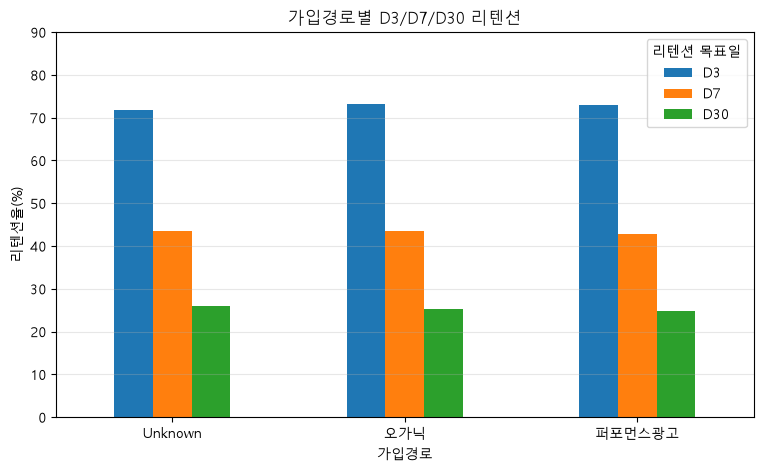

가입경로별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
signup_channel,,,,,
Unknown,71.85,43.61,25.98,28.24,17.63
오가닉,73.16,43.41,25.34,29.75,18.07
퍼포먼스광고,73.01,42.89,24.87,30.12,18.02


In [31]:
channel_plot_data = channel_retention_rate_table[["D3", "D7", "D30"]]

ax = channel_plot_data.plot(kind="bar", figsize=(9, 5))
ax.set_title("가입경로별 D3/D7/D30 리텐션")
ax.set_xlabel("가입경로")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 90)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

channel_drop_table = channel_retention_rate_table[["D3", "D7", "D30"]].copy()

channel_drop_table["D3_to_D7_drop"] = (
    channel_drop_table["D3"] - channel_drop_table["D7"]
).round(2)

channel_drop_table["D7_to_D30_drop"] = (
    channel_drop_table["D7"] - channel_drop_table["D30"]
).round(2)

print("가입경로별 리텐션 하락폭")
display(channel_drop_table)

### 분석 결과 해석

가입경로별 리텐션 차이는 D3, D7, D30 모두에서 크지 않다.

| 가입경로 | D3 | D7 | D30 |
|---|---:|---:|---:|
| 오가닉 | 73.16% | 43.41% | 25.34% |
| 퍼포먼스광고 | 73.01% | 42.89% | 24.87% |

오가닉 유입이 퍼포먼스광고 유입보다 약간 높지만, 차이는 매우 작다.  
D3 → D7 하락폭도 오가닉 29.75%p, 퍼포먼스광고 30.12%p로 거의 비슷하게 나타난다.

따라서 현재 결과만 보면 리텐션 하락의 핵심 원인을 특정 가입경로의 유입 품질 문제로 보기에는 근거가 약하다.  
2월 가입자 수 급증도 리텐션 악화로 바로 이어졌다고 보기보다는, 이후 온보딩/챌린지 경험 차이를 함께 확인하는 것이 더 중요하다.


## 5. 기기별 리텐션 분석

### 분석 목적

특정 기기 환경에서 리텐션이 낮게 나타나는지 확인한다.

기기별 차이가 크다면 사용성 문제나 기술적 이슈 가능성을 검토할 수 있다.


In [32]:
device_retention_summary = (
    behavior_retention_base[
        behavior_retention_base["is_retention_calculation_target"]
    ]
    .groupby(["device", "retention_label"], as_index=False)
    .agg(
        target_user_count=("user_id", "nunique"),
        retained_user_count=("is_retained_for_calculation", "sum")
    )
)

# 기기별 리텐션율을 계산
device_retention_summary["retention_rate"] = (
    device_retention_summary["retained_user_count"]
    / device_retention_summary["target_user_count"]
    * 100
).round(2)

# 리텐션 목표일 순서를 지정
device_retention_summary["retention_label"] = pd.Categorical(
    device_retention_summary["retention_label"],
    categories=retention_order,
    ordered=True
)

# 기기, 리텐션 목표일 순서로 정렬
device_retention_summary = device_retention_summary.sort_values(
    ["device", "retention_label"]
)

# 기기별 리텐션율 표
device_retention_rate_table = (
    device_retention_summary
    .pivot(index="device", columns="retention_label", values="retention_rate")
)

# 기기별 유지 사용자 수 표
device_retention_count_table = (
    device_retention_summary
    .pivot(index="device", columns="retention_label", values="retained_user_count")
)

print("기기별 리텐션율")
display(device_retention_rate_table)

print("기기별 리텐션 유지 사용자 수")
display(device_retention_count_table)

기기별 리텐션율


retention_label,D0,D3,D7,D30
device,,,,
Android,99.76,73.21,43.27,25.28
Unknown,100.00,69.23,40.87,27.68
iOS,99.86,73.02,43.06,24.91


기기별 리텐션 유지 사용자 수


retention_label,D0,D3,D7,D30
device,,,,
Android,5043,3709,2192,1234
Unknown,116,81,47,31
iOS,6978,5094,2993,1678


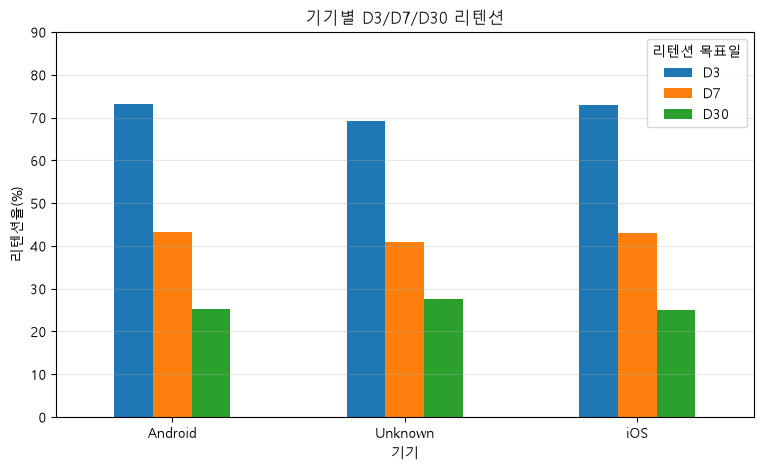

기기별 리텐션 하락폭


retention_label,D3,D7,D30,D3_to_D7_drop,D7_to_D30_drop
device,,,,,
Android,73.21,43.27,25.28,29.94,17.99
Unknown,69.23,40.87,27.68,28.36,13.19
iOS,73.02,43.06,24.91,29.96,18.15


In [33]:
device_plot_data = device_retention_rate_table[["D3", "D7", "D30"]]

ax = device_plot_data.plot(kind="bar", figsize=(9, 5))
ax.set_title("기기별 D3/D7/D30 리텐션")
ax.set_xlabel("기기")
ax.set_ylabel("리텐션율(%)")
ax.set_ylim(0, 90)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="리텐션 목표일")
plt.xticks(rotation=0)
plt.show()

device_drop_table = device_retention_rate_table[["D3", "D7", "D30"]].copy()

device_drop_table["D3_to_D7_drop"] = (
    device_drop_table["D3"] - device_drop_table["D7"]
).round(2)

device_drop_table["D7_to_D30_drop"] = (
    device_drop_table["D7"] - device_drop_table["D30"]
).round(2)

print("기기별 리텐션 하락폭")
display(device_drop_table)

### 분석 결과 해석

기기별 리텐션 차이도 D3, D7, D30 모두에서 크지 않다.

| 기기 | D3 | D7 | D30 |
|---|---:|---:|---:|
| Android | 73.21% | 43.27% | 25.28% |
| iOS | 73.02% | 43.06% | 24.91% |

Android와 iOS의 리텐션은 거의 비슷하게 나타난다.  
D3 → D7 하락폭도 Android 29.94%p, iOS 29.96%p로 차이가 거의 없다.

따라서 현재 데이터에서는 특정 기기 환경이 리텐션 하락의 핵심 원인이라고 보기는 어렵다.  
기기별 분석은 핵심 원인이라기보다, 기술적 이슈 가능성을 배제하는 보조 분석으로 보는 것이 적절하다.

## 리텐션 하락 원인 분석 1차 정리

이번 분석에서는 가입월별 코호트 분석에서 확인한 D3 → D7 이탈 문제를 바탕으로, 초기 행동 경험별 리텐션 차이를 확인했다.  
따라서 각 분석에서 D30 리텐션뿐 아니라 **D3 → D7 하락폭**도 함께 확인했다.

| 분석 항목 | 핵심 결과 | 해석 |
|---|---|---|
| 온보딩 완료 여부 | 완료자가 D3/D7/D30 모두 미완료자보다 높음 | 온보딩 완료는 장기 잔존과 연결되는 초기 신호지만, D3 → D7 이탈을 단독으로 설명하기는 어려움 |
| 첫 7일 내 챌린지 경험 | 참여자가 D7 52.23%, D30 31.84%로 미경험자보다 크게 높음 | D3 → D7 이탈과 D30 잔존을 설명하는 가장 강한 행동 신호 |
| 알림 수신/오픈 여부 | 알림 오픈자는 D30 32.53%로 높지만, 수신만 한 사용자는 17.08%로 낮음 | 단순 알림 발송보다 실제 오픈과 앱 내 행동 연결이 중요 |
| 가입경로 | 오가닉/퍼포먼스광고의 D3/D7/D30 차이가 작음 | 유입경로 자체가 핵심 원인이라고 보기는 어려움 |
| 기기 | Android/iOS의 D3/D7/D30 차이가 작음 | 특정 기기 환경 문제가 핵심 원인이라고 보기는 어려움 |

### 종합 해석

이번 리텐션 하락 원인 분석에서 확인한 핵심 내용은 다음과 같다.

1. 온보딩 완료자는 미완료자보다 D3/D7/D30 리텐션이 모두 높다.   
온보딩 완료자는 D30 리텐션이 30.30%로, 미완료자 20.72%보다 높게 나타났다.       
다만 D3 → D7 하락폭은 두 그룹 모두 크게 나타나므로, 온보딩만으로 D3 → D7 이탈을 모두 설명하기는 어렵다.

2. 첫 7일 내 챌린지 참여자는 미경험자보다 리텐션이 높다.            
챌린지 참여자는 D7 리텐션 52.23%, D30 리텐션 31.84%로 높게 나타났다.                
따라서 첫 7일 내 챌린지 참여 경험은 초기 이탈을 줄이고 장기 잔존으로 이어지는 중요한 행동 신호로 볼 수 있다.        

3. 다만, 챌린지 탐색 경험도 리텐션과 연결될 수 있지만, 실제 참여까지 이어진 사용자와는 차이가 있다.         
따라서 단순 탐색보다 실제 챌린지 참여 여부를 더 중요한 기준으로 보는 것이 적절하다.     

4. 알림은 단순 수신보다 오픈 여부가 더 중요하다.                
알림 오픈자는 D30 리텐션이 32.53%로 높게 나타난 반면, 알림을 수신만 하고 오픈하지 않은 사용자는 17.08%로 낮게 나타났다.             
즉, 알림 발송량 자체보다 사용자가 알림을 열고 앱 안의 행동으로 이어지는지가 더 중요하다.        

5. 가입경로와 기기별 리텐션 차이는 상대적으로 크지 않다.                
가입경로와 기기별 리텐션 차이는 온보딩, 챌린지, 알림 오픈 여부에서 나타난 차이보다 작게 나타났다.               
따라서 현재 리텐션 하락 원인은 유입경로나 기기 환경보다는 가입 초기 행동 경험과 더 관련이 있다고 볼 수 있다.        




# 분석 정리

지금까지 진행한 코호트/리텐션 분석 결과를 최종 보고서와 조원 공유용으로 정리한다.  
이번 파트의 목적은 새로운 분석을 추가하는 것이 아니라, 앞에서 계산한 결과를 바탕으로 **리텐션 하락 구간, 원인 후보, 전략 연결 방향**을 한 번에 확인하는 것이다.


## 1. 이번 분석에서 답한 질문

| 구분 | 질문 | 답변 |
|---|---|---|
| 문제 위치 | 리텐션은 어디서 가장 많이 떨어지는가? | D3 → D7 구간에서 가장 큰 이탈이 반복적으로 나타난다. |
| 초기 경험 | 온보딩 완료 여부가 리텐션과 연결되는가? | 온보딩 완료자는 미완료자보다 D3/D7/D30 리텐션이 모두 높다. |
| 핵심 행동 | 첫 7일 내 챌린지 경험이 리텐션과 연결되는가? | 챌린지 참여자는 미경험자보다 D7/D30 리텐션이 높고, D3 → D7 하락폭도 상대적으로 작다. |
| 알림 효과 | 알림 수신/오픈 여부가 리텐션과 연결되는가? | 단순 수신보다 실제 오픈 여부가 중요하다. |
| 유입/환경 | 가입경로나 기기 차이가 핵심 원인인가? | 차이는 존재하지만, 온보딩/챌린지/알림 오픈 여부보다 영향이 작다. |


## 2. 가입월별 코호트 분석 요약

| 핵심 내용 | 해석 |
|---|---|
| D0 리텐션은 모든 가입월에서 약 99.7% 이상 | 가입 직후 앱실행 단계는 큰 문제로 보기 어렵다. |
| 가장 큰 이탈 구간은 D3 → D7 | 모든 가입월에서 해당 구간의 하락폭이 약 29~31%p 수준으로 반복된다. |
| D30 리텐션은 2월 코호트가 가장 높고, 4~5월 코호트가 낮음 | 2월 가입자 수 급증이 리텐션 악화로 바로 이어졌다고 보기는 어렵다. |
| 최근 코호트는 D7 이후 D30까지 이어지는 장기 잔존이 약함 | 특히 5월 코호트는 D7 → D30 하락폭이 21.54%p로 가장 크다. |
| 장애기간 영향은 분리해서 해석 필요 | 3월 D0/D3/D7은 장애기간을 포함하면 리텐션이 과소평가될 수 있다. |

### 해석

가입월별 코호트 분석을 통해 리텐션 하락이 가입 직후 앱실행 실패에서 발생하는 문제라기보다, 가입 후 며칠이 지난 뒤 사용자가 습관 형성 단계로 넘어가지 못하는 문제일 가능성을 확인했다.

특히 모든 가입월에서 D3 → D7 구간의 이탈폭이 반복적으로 크게 나타났기 때문에, 이후 분석에서는 가입월 자체보다 사용자의 초기 행동 경험에 따라 리텐션이 어떻게 달라지는지 확인했다.


## 3. 리텐션 하락 원인 분석 요약

| 분석 항목 | 핵심 결과 | 해석 |
|---|---|---|
| 온보딩 완료 여부 | 완료자가 D3/D7/D30 모두 미완료자보다 높음 | 온보딩 완료는 장기 잔존과 연결되는 초기 신호지만, D3 → D7 이탈을 단독으로 설명하기는 어렵다. |
| 첫 7일 내 챌린지 경험 | 참여자가 D7/D30 리텐션에서 가장 좋은 흐름을 보임 | 첫 7일 내 챌린지 참여는 초기 이탈 완화와 장기 잔존을 설명하는 가장 강한 행동 신호로 볼 수 있다. |
| 알림 수신/오픈 여부 | 알림 오픈자는 높고, 수신만 한 사용자는 낮음 | 단순 알림 발송량보다 실제 오픈과 앱 내 행동 연결이 중요하다. |
| 가입경로 | 오가닉/퍼포먼스광고 리텐션 차이는 상대적으로 작음 | 2월 가입자 수 급증을 리텐션 악화의 직접 원인으로 보기는 어렵다. |
| 기기 | Android/iOS 리텐션 차이는 상대적으로 작음 | 특정 기기 환경 문제가 리텐션 하락의 핵심 원인이라고 보기는 어렵다. |


## 4. 종합 해석

이번 분석에서 확인한 핵심 내용은 다음과 같다.

1. **가입 직후 앱실행 단계는 큰 문제로 보기 어렵다.**  
   D0 리텐션이 모든 가입월에서 매우 높게 나타났기 때문에, 사용자가 가입 직후 앱을 실행하지 못해서 이탈한다고 보기는 어렵다.

2. **핵심 이탈 구간은 D3 → D7이다.**  
   모든 가입월에서 D3 → D7 구간의 하락폭이 가장 크게 나타났다.  
   따라서 리텐션 개선의 핵심은 가입 후 첫 1주일 안에 사용자가 앱 사용 이유를 찾도록 만드는 것이다.

3. **온보딩 완료 여부는 장기 잔존과 연결되는 초기 신호이다.**  
   온보딩 완료자는 미완료자보다 D3/D7/D30 리텐션이 모두 높다.  
   다만 D3 → D7 이탈은 온보딩 완료자에게도 크게 나타나므로, 온보딩 완료만으로 문제를 모두 설명하기는 어렵다.

4. **첫 7일 내 챌린지 참여가 가장 중요한 행동 신호로 보인다.**  
   챌린지 참여자는 미경험자보다 D7/D30 리텐션이 높고, D3 → D7 하락폭도 상대적으로 작다.  
   따라서 사용자를 단순히 챌린지 화면에 노출시키는 것보다, 실제 참여까지 연결하는 것이 중요하다.

5. **알림은 발송량보다 오픈과 행동 연결이 중요하다.**  
   알림 오픈자는 높은 리텐션을 보였지만, 수신만 하고 오픈하지 않은 사용자는 낮은 리텐션을 보였다.  
   알림은 많이 보내는 것보다 사용자가 열고 앱 안의 행동으로 이어지게 만드는 방식이 중요하다.

6. **가입경로와 기기 차이는 핵심 원인으로 보기 어렵다.**  
   가입경로와 기기별 리텐션 차이는 온보딩, 챌린지, 알림 오픈 여부에 따른 차이보다 작았다.  
   따라서 현재 리텐션 하락은 유입 품질이나 기기 환경보다 가입 초기 행동 경험과 더 관련이 있다고 볼 수 있다.


## 5. 데이터 한계 및 해석 주의

이번 분석은 제공된 로그 데이터를 기준으로 진행했기 때문에 다음 한계를 함께 고려해야 한다.

| 한계 | 영향 |
|---|---|
| 2025년 3월 10일 ~ 3월 14일 로그 수집 장애 | 해당 기간과 겹치는 리텐션 목표일 또는 첫 7일 행동 경험이 과소 관측될 수 있다. |
| 첫 7일 내 행동 경험의 과소 분류 가능성 | 실제로 온보딩/챌린지/알림 행동이 있었지만 로그 누락으로 미경험자로 분류되었을 가능성이 있다. |
| 챌린지 속성 데이터 부재 | 어떤 종류의 챌린지가 리텐션에 더 효과적인지는 확인할 수 없다. |
| 이탈 전 마지막 화면/행동 데이터 부재 | 사용자가 정확히 어느 화면이나 단계에서 이탈했는지는 확인하기 어렵다. |

### 한계 정리 문장

로그 수집 장애기간과 리텐션 목표일이 겹치는 경우는 정상 산정 대상에서 제외했다.  
다만 첫 7일 내 행동 경험 분석의 경우, 가입 후 7일 구간이 장애기간과 겹친 사용자는 실제 온보딩/챌린지/알림 행동이 과소 관측되었을 가능성이 있다.  
따라서 온보딩 미완료, 챌린지 미경험, 알림 미오픈 그룹은 일부 과대 분류되었을 수 있으며, 최종 해석에서는 이를 데이터 한계로 함께 명시한다.


## 6. 최종 한 문장 결론

가입월별 코호트 분석에서 D3 → D7 구간이 가장 큰 이탈 구간으로 확인되었고, 행동 경험별 리텐션 분석에서는 첫 7일 내 챌린지 참여 여부가 D30 리텐션과 가장 강하게 연결되는 신호로 나타났다.  
따라서 다음 분기 리텐션 개선 전략은 가입 직후 앱실행을 늘리는 것보다, 온보딩 이후 사용자가 첫 7일 안에 챌린지 참여까지 도달하도록 유도하는 방향으로 설계하는 것이 적절하다.


---

# 통계를 위한 데이터 저장

코호트 분석과 리텐션 하락 원인 분석에서 만든 결과를 다음 통계검정 노트북에서 바로 사용할 수 있도록 저장

In [34]:
# 통계를 위한 데이터 저장

# 통계검정용 행 단위 데이터 생성
stat_test_retention_base = (
    behavior_retention_base
    .merge(
        challenge_first7_user[["user_id", "challenge_first7_group"]],
        on="user_id",
        how="left"
    )
    .merge(
        notification_first7_user[["user_id", "notification_first7_group"]],
        on="user_id",
        how="left"
    )
)

# 첫 7일 행동 분석에서 사용할 주 분석 대상 표시
stat_test_retention_base["is_behavior_analysis_target"] = (
    stat_test_retention_base["is_retention_calculation_target"]
    & ~stat_test_retention_base["is_first7_log_issue_overlap"].fillna(False)
)

# 통계검정에 필요한 컬럼만 선택
stat_test_retention_base = stat_test_retention_base[[
    "user_id",
    "signup_day",
    "signup_month",
    "retention_label",
    "target_date",
    "is_retention_calculation_target",
    "is_retained_for_calculation",
    "onboarding_group",
    "challenge_first7_group",
    "notification_first7_group",
    "signup_channel",
    "device",
    "is_no_event_user",
    "is_signup_log_issue_period",
    "is_target_log_issue_period",
    "is_first7_log_issue_overlap",
    "is_behavior_analysis_target"
]].copy()

# 통계검정은 리텐션 목표일이 정상 산정 가능한 행만 저장
# 첫 7일 장애기간 중복 여부는 컬럼으로 남겨 다음 통계검정 노트북에서 주 분석/민감도 분석에 활용
stat_test_retention_base = stat_test_retention_base[
    stat_test_retention_base["is_retention_calculation_target"]
].copy()

# 통계검정에서 사용하기 쉽도록 리텐션 유지 여부를 0/1로 변환
stat_test_retention_base["retained"] = (
    stat_test_retention_base["is_retained_for_calculation"]
    .astype(int)
)

# 통계검정용 데이터 저장 경로
STAT_TEST_DATA_DIR = DATA_PROCESSED_DIR
STAT_TEST_DATA_DIR.mkdir(parents=True, exist_ok=True)

STAT_TEST_RETENTION_BASE_PATH = STAT_TEST_DATA_DIR / "03_stat_test_retention_base.csv"

# 다음 통계검정 노트북에서 불러올 CSV 저장
stat_test_retention_base.to_csv(
    STAT_TEST_RETENTION_BASE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("통계검정용 데이터 저장 완료")
print("행 단위 데이터:", STAT_TEST_RETENTION_BASE_PATH)

display(stat_test_retention_base.head())


통계검정용 데이터 저장 완료
행 단위 데이터: C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\03_stat_test_retention_base.csv


,user_id,signup_day,signup_month,retention_label,target_date,is_retention_calculation_target,is_retained_for_calculation,onboarding_group,challenge_first7_group,notification_first7_group,signup_channel,device,is_no_event_user,is_signup_log_issue_period,is_target_log_issue_period,is_first7_log_issue_overlap,is_behavior_analysis_target,retained
0,U0000001,2025-01-25,2025-01,D0,2025-01-25,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
1,U0000001,2025-01-25,2025-01,D3,2025-01-28,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
2,U0000001,2025-01-25,2025-01,D7,2025-02-01,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
3,U0000001,2025-01-25,2025-01,D30,2025-02-24,True,True,온보딩 완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 오픈,오가닉,iOS,False,False,False,False,True,1
4,U0000002,2025-05-06,2025-05,D0,2025-05-06,True,True,온보딩 미완료,첫 7일 내 챌린지 참여,첫 7일 내 알림 없음,오가닉,iOS,False,False,False,False,True,1
